# KeyPoint MoSeq Testing
Runs KeyPoint-MoSeq on sleap tracks. Objective is to evaluate feasability and output useful figures/videos.

NOTES:
- Filepath strings can't have brackets (need to change how campy makes session names)

## 1. Setup

In [98]:
### Imports.

import os
import cv2
import numpy as np
import networkx as nx
from tqdm import trange
import keypoint_moseq as kpms
import matplotlib.pyplot as plt

In [2]:
### Variables.

CAMERA_DIRECTORY = r"Z:/Ben/Projects/StressDASert/Behavior/Data/SleapTrainVideos/2024-09-25/Bl6SW_2/(2024-09-25_13-43-44)-SleapTrain_Bl6SW_2/Camera2"
CAMERA_VIDEO_FILENAME = [f for f in os.listdir(CAMERA_DIRECTORY) if f.endswith(".mp4") and "tracks" not in f][0]
CAMERA_VIDEO_FILEPATH = CAMERA_DIRECTORY + "/" + CAMERA_VIDEO_FILENAME
TRACKS_FILEPATH = os.path.join(CAMERA_DIRECTORY, "black_inference.slp")
SESSION_NAME = CAMERA_DIRECTORY.split("/")[-2]

TRACKS_FILEPATH_3D = r"Z:/Ben/Projects/StressDASert/Behavior/Data/SleapTrainVideos/2024-09-25/Bl6SW_2/(2024-09-25_13-43-44)-SleapTrain_Bl6SW_2/black_triangulated.h5"

In [3]:
### Make sure all filepath exist.

assert os.path.exists(CAMERA_VIDEO_FILEPATH), f"Camera video file does not exist: {CAMERA_VIDEO_FILEPATH}"
assert os.path.exists(TRACKS_FILEPATH), f"Tracks file does not exist: {TRACKS_FILEPATH}"
assert os.path.exists(TRACKS_FILEPATH_3D), f"3D Tracks file does not exist: {TRACKS_FILEPATH_3D}"

## 2. KPMS initialization and configuration

In [4]:
### Create new KPMS project.

# Load config.
project_dir = os.path.join(os.getcwd(), f"{SESSION_NAME}_test_project")
config = lambda: kpms.load_config(project_dir)

# Load sleap file. NOTE: using original tracks file for overhead view for project setup.
kpms.setup_project(project_dir, sleap_file=TRACKS_FILEPATH, overwrite=True)

# Update config file with parameters for tracking.
kpms.update_config(
    project_dir,
    video_dir=CAMERA_VIDEO_FILEPATH,
    anterior_bodyparts=["Nose"],
    posterior_bodyparts=["TTI"],
    use_bodyparts=["Nose", "Ear_L", "Ear_R", "Head", "Neck", "Shoulder_left",
                    "Shoulder_right", "Haunch_left", "Haunch_right", "Trunk", "TTI"] # Use everything but the tail.
)

# Load data.
coordinates, confidences, bodyparts = kpms.load_keypoints(TRACKS_FILEPATH_3D, "sleap-anipose")

# format data for modeling
data, metadata = kpms.format_data(coordinates, confidences, **config())

Loading keypoints: 100%|██████████████████| 1/1 [00:00<00:00,  1.46it/s]


In [5]:
### Calibration.
# NOTE: only supported for 2D tracking.

# kpms.noise_calibration(project_dir, coordinates, confidences, **config())

>=90.0% of variance exlained by 6 components.


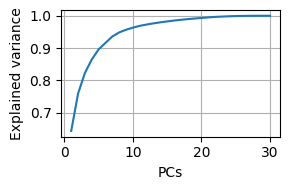

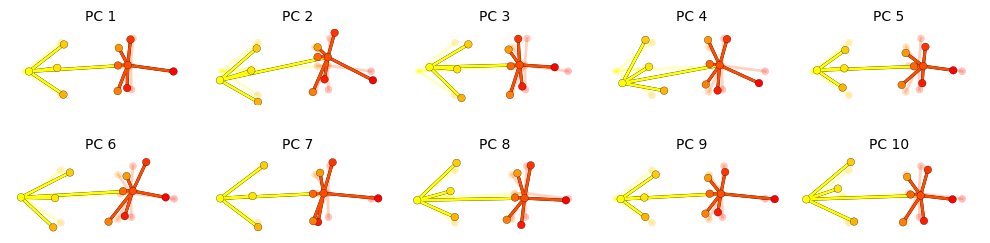

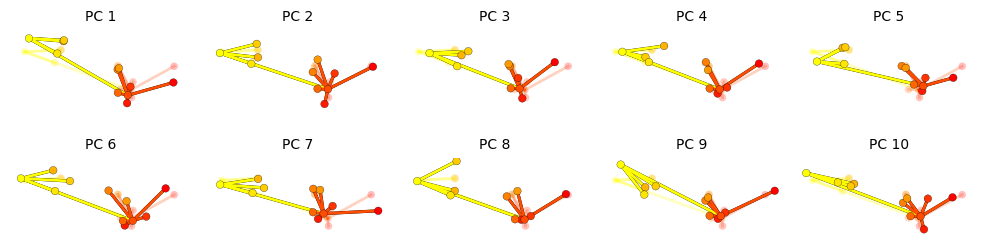

Saved interactive plot to z:\Ben\Projects\StressDASert\Behavior\Scripts\(2024-09-25_13-43-44)-SleapTrain_Bl6SW_2_test_project\pcs.html


In [6]:
### Fit PCA.

pca = kpms.fit_pca(**data, **config())
kpms.save_pca(pca, project_dir)

kpms.print_dims_to_explain_variance(pca, 0.9)
kpms.plot_scree(pca, project_dir=project_dir)
kpms.plot_pcs(pca, project_dir=project_dir, **config());

In [7]:
### Update number of latent dimensions to equal number of PCs needed for 90% variance explained.

kpms.update_config(project_dir, latent_dim=6) # 6 PCs needed for 90% variance explained.

## 3. Kappa sweep

Fitting model with kappa=1000000.0
Outputs will be saved to z:\Ben\Projects\StressDASert\Behavior\Scripts
\(2024-09-25_13-43-44)-SleapTrain_Bl6SW_2_test_project\kappa_sweep-100
0000.0


 49%|█████████████████▏                 | 25/51 [00:09<00:10,  2.56it/s]

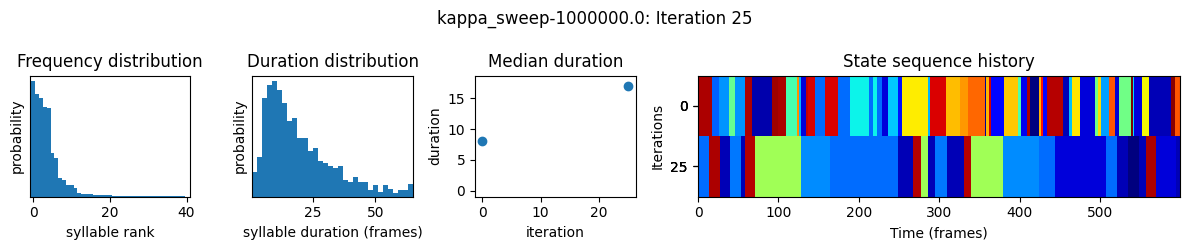

 98%|██████████████████████████████████▎| 50/51 [00:20<00:00,  2.49it/s]

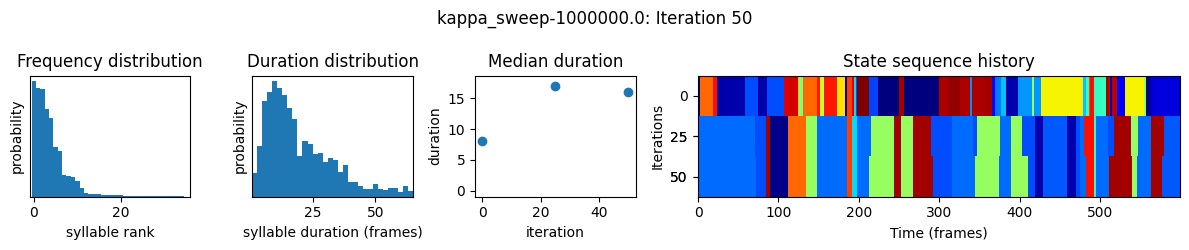

100%|███████████████████████████████████| 51/51 [00:22<00:00,  2.22it/s]


Outputs will be saved to z:\Ben\Projects\StressDASert\Behavior\Scripts
\(2024-09-25_13-43-44)-SleapTrain_Bl6SW_2_test_project\kappa_sweep-100
0000.0


 17%|█████▋                            | 25/151 [00:57<04:52,  2.32s/it]

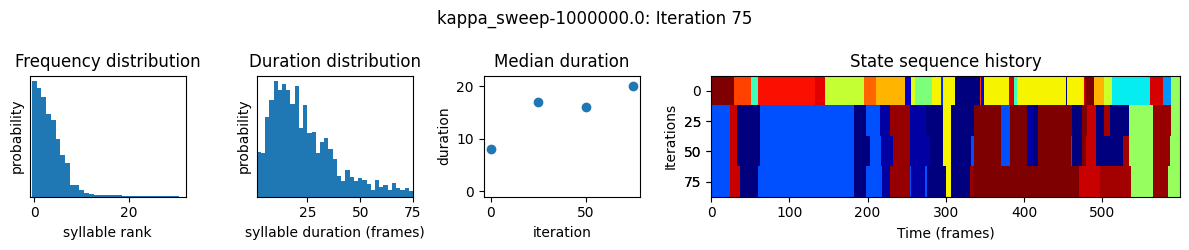

 33%|███████████▎                      | 50/151 [01:55<03:51,  2.29s/it]

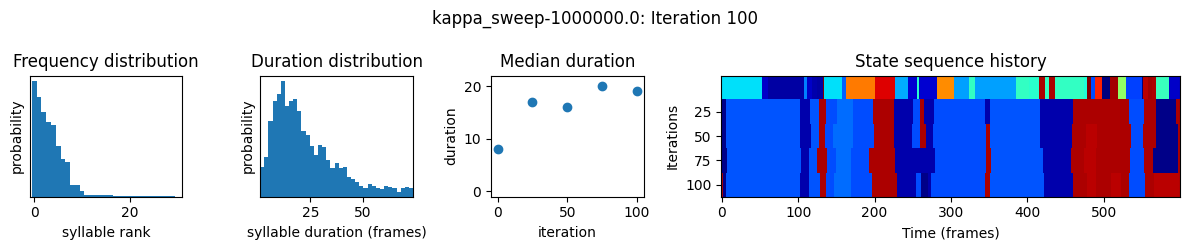

 50%|████████████████▉                 | 75/151 [02:53<02:56,  2.32s/it]

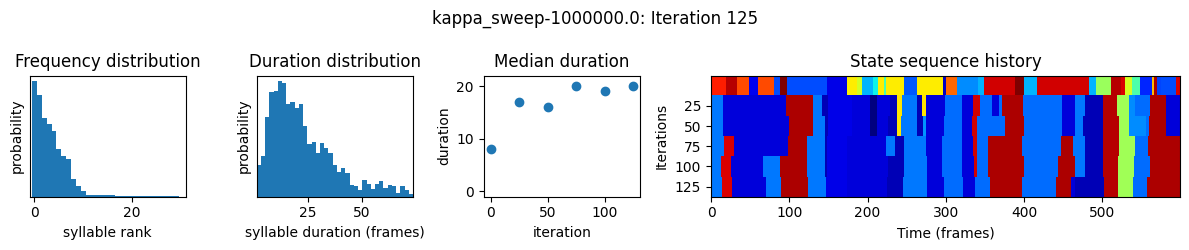

 66%|█████████████████████▊           | 100/151 [03:51<01:57,  2.30s/it]

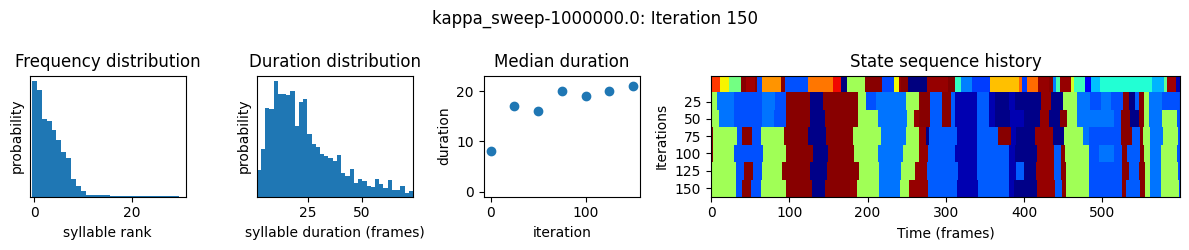

 83%|███████████████████████████▎     | 125/151 [04:49<00:59,  2.29s/it]

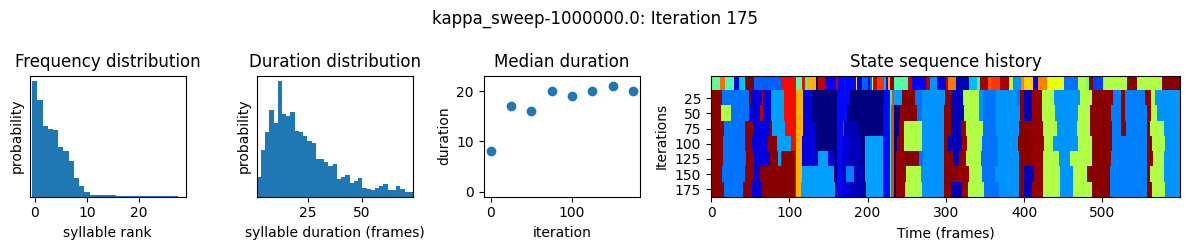

 99%|████████████████████████████████▊| 150/151 [05:48<00:02,  2.31s/it]

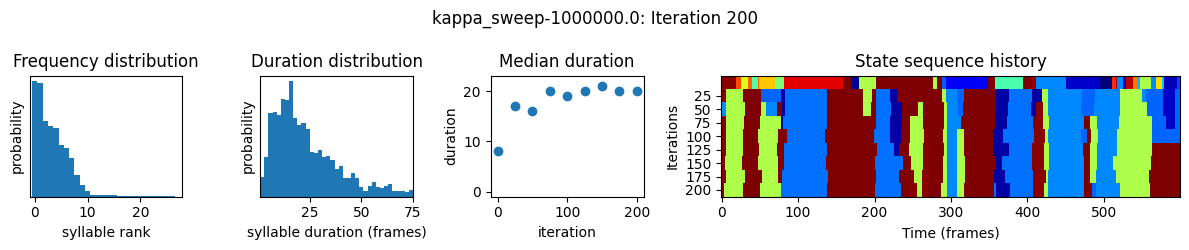

100%|█████████████████████████████████| 151/151 [05:51<00:00,  2.33s/it]


Fitting model with kappa=31622776.60168379
Outputs will be saved to z:\Ben\Projects\StressDASert\Behavior\Scripts
\(2024-09-25_13-43-44)-SleapTrain_Bl6SW_2_test_project\kappa_sweep-316
22776.60168379


 49%|█████████████████▏                 | 25/51 [00:09<00:10,  2.56it/s]

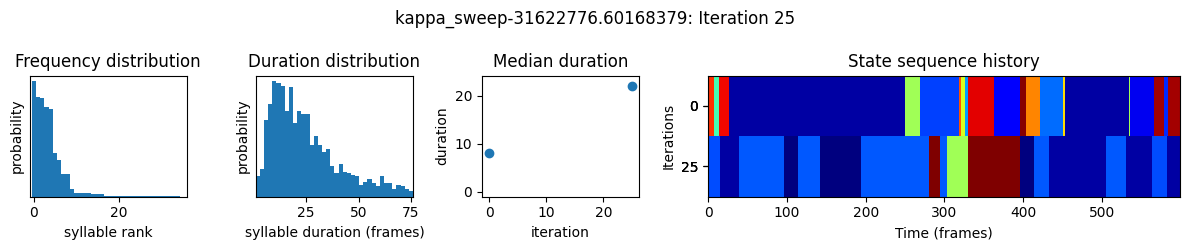

 98%|██████████████████████████████████▎| 50/51 [00:20<00:00,  2.55it/s]

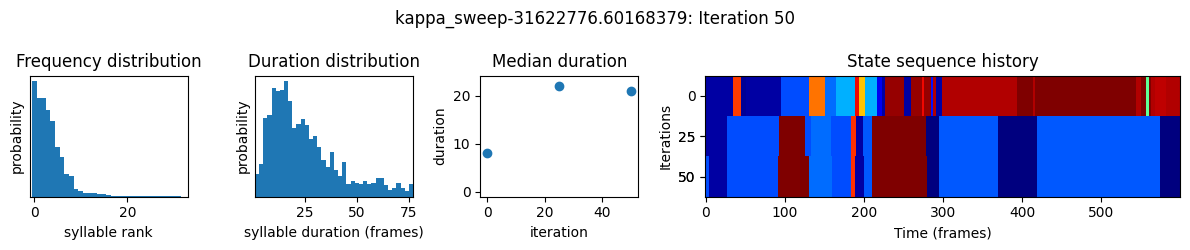

100%|███████████████████████████████████| 51/51 [00:21<00:00,  2.40it/s]


Outputs will be saved to z:\Ben\Projects\StressDASert\Behavior\Scripts
\(2024-09-25_13-43-44)-SleapTrain_Bl6SW_2_test_project\kappa_sweep-316
22776.60168379


 17%|█████▋                            | 25/151 [01:00<05:06,  2.43s/it]

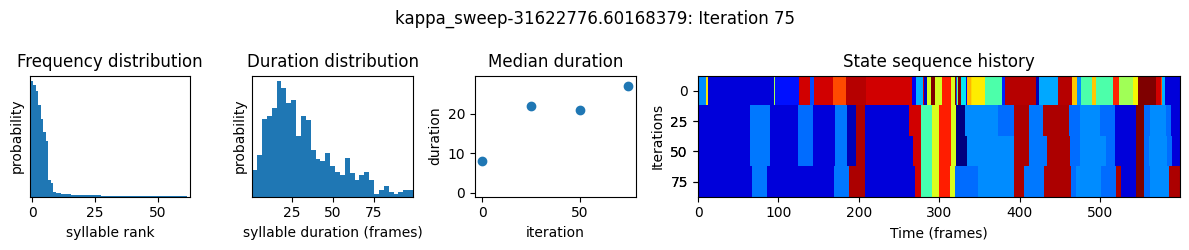

 33%|███████████▎                      | 50/151 [02:01<04:05,  2.43s/it]

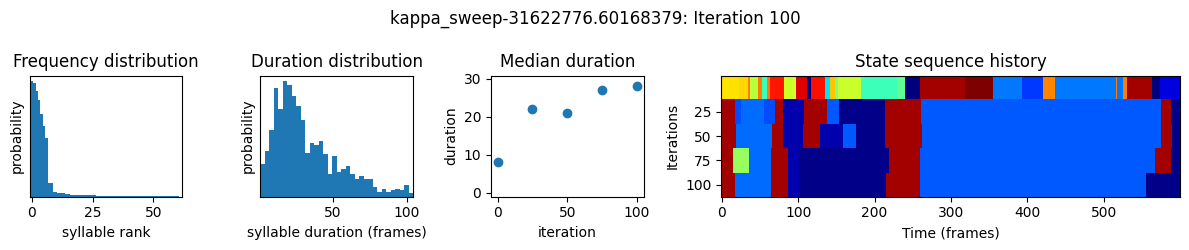

 50%|████████████████▉                 | 75/151 [03:02<03:03,  2.42s/it]

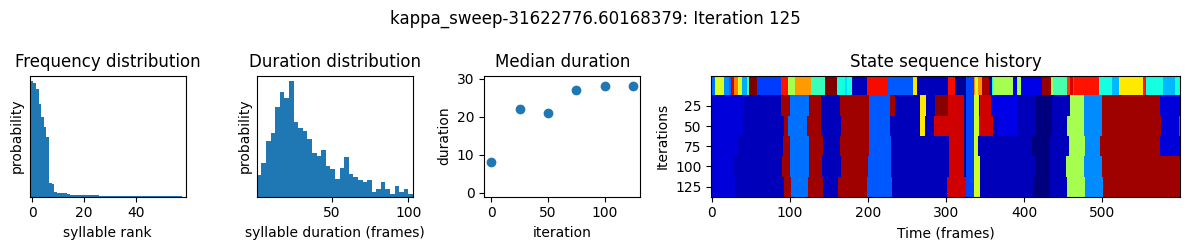

 66%|█████████████████████▊           | 100/151 [04:03<02:03,  2.42s/it]

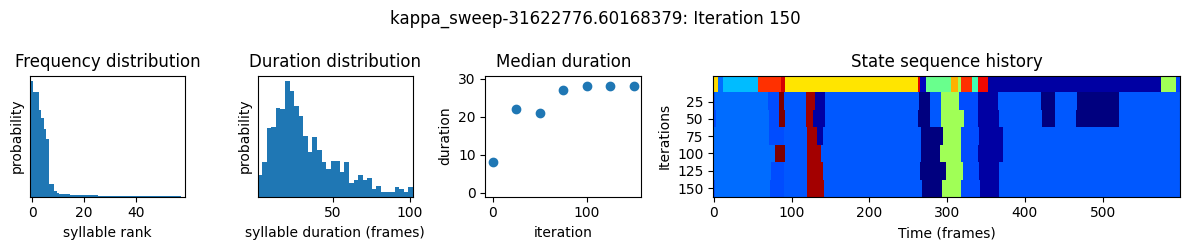

 83%|███████████████████████████▎     | 125/151 [05:04<01:02,  2.42s/it]

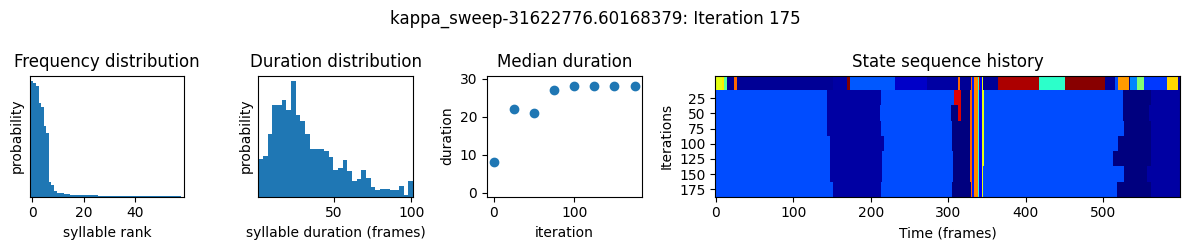

 99%|████████████████████████████████▊| 150/151 [06:05<00:02,  2.39s/it]

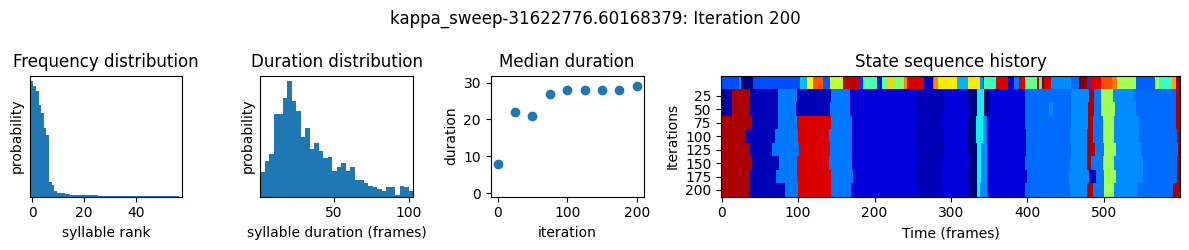

100%|█████████████████████████████████| 151/151 [06:08<00:00,  2.44s/it]


Fitting model with kappa=1000000000.0
Outputs will be saved to z:\Ben\Projects\StressDASert\Behavior\Scripts
\(2024-09-25_13-43-44)-SleapTrain_Bl6SW_2_test_project\kappa_sweep-100
0000000.0


 49%|█████████████████▏                 | 25/51 [00:10<00:10,  2.45it/s]

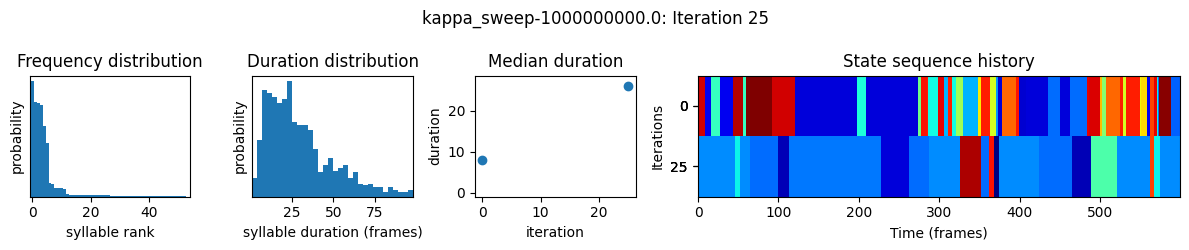

 98%|██████████████████████████████████▎| 50/51 [00:21<00:00,  2.33it/s]

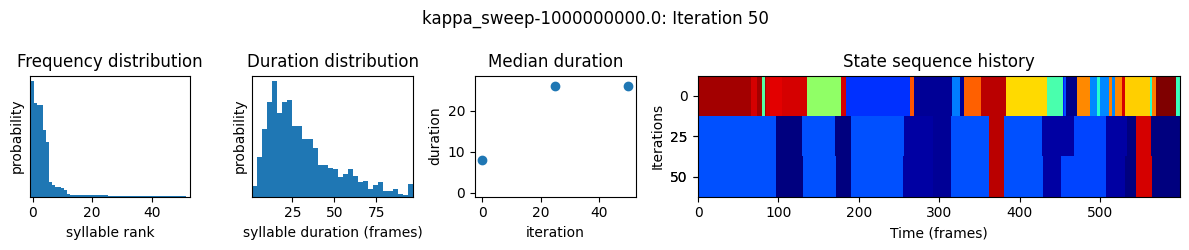

100%|███████████████████████████████████| 51/51 [00:22<00:00,  2.29it/s]


Outputs will be saved to z:\Ben\Projects\StressDASert\Behavior\Scripts
\(2024-09-25_13-43-44)-SleapTrain_Bl6SW_2_test_project\kappa_sweep-100
0000000.0


 17%|█████▋                            | 25/151 [00:57<04:50,  2.30s/it]

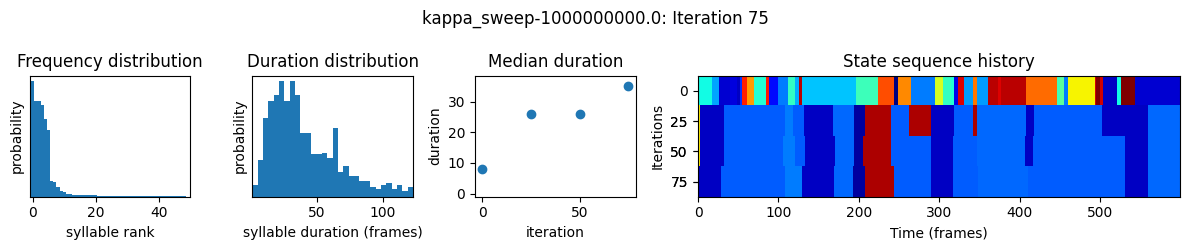

 33%|███████████▎                      | 50/151 [01:55<03:50,  2.28s/it]

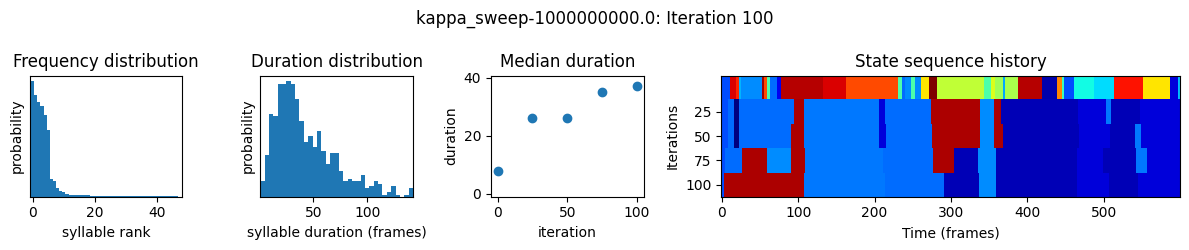

 50%|████████████████▉                 | 75/151 [02:54<02:58,  2.34s/it]

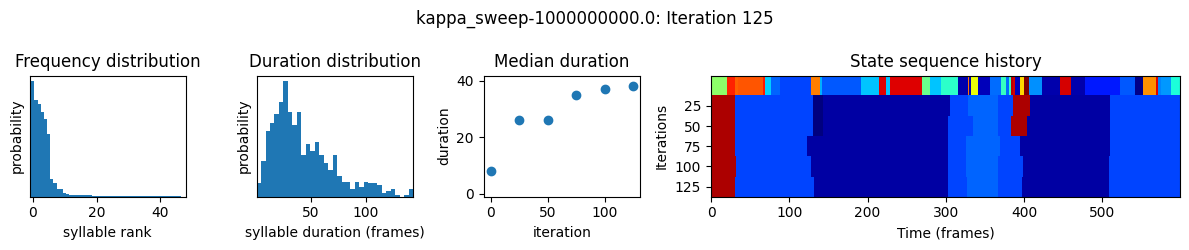

 66%|█████████████████████▊           | 100/151 [03:52<01:58,  2.32s/it]

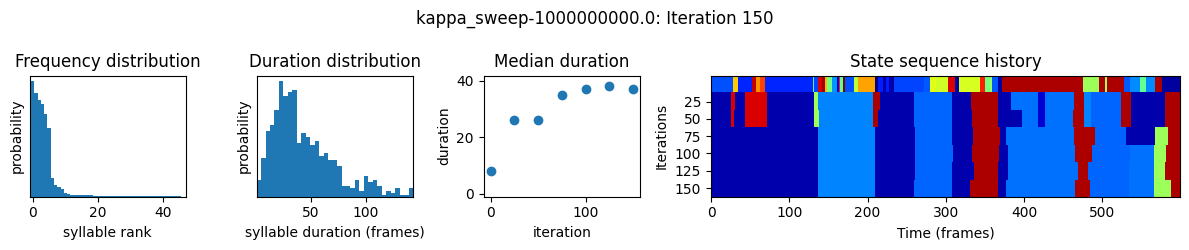

 83%|███████████████████████████▎     | 125/151 [04:51<01:01,  2.37s/it]

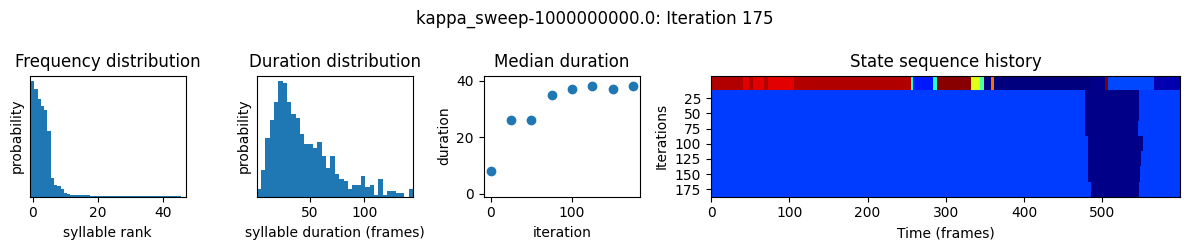

 99%|████████████████████████████████▊| 150/151 [05:50<00:02,  2.32s/it]

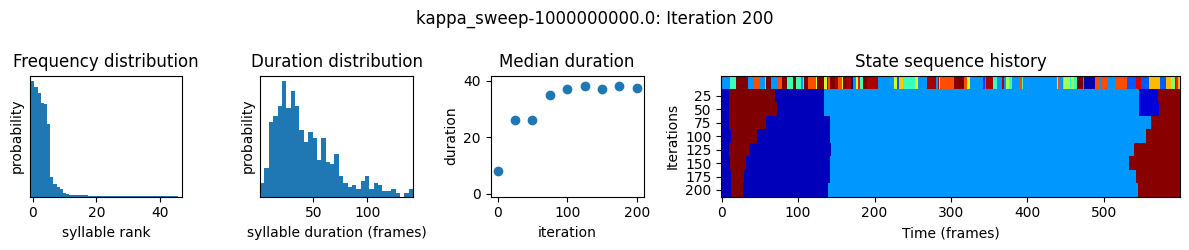

100%|█████████████████████████████████| 151/151 [05:52<00:00,  2.34s/it]


Fitting model with kappa=31622776601.683792
Outputs will be saved to z:\Ben\Projects\StressDASert\Behavior\Scripts
\(2024-09-25_13-43-44)-SleapTrain_Bl6SW_2_test_project\kappa_sweep-316
22776601.683792


 49%|█████████████████▏                 | 25/51 [00:10<00:10,  2.52it/s]

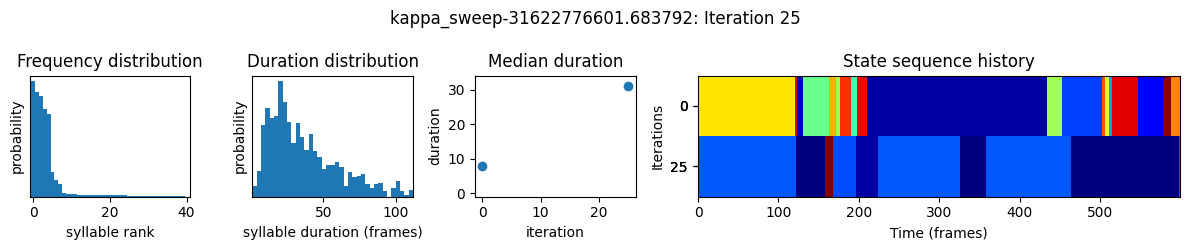

 98%|██████████████████████████████████▎| 50/51 [00:20<00:00,  2.55it/s]

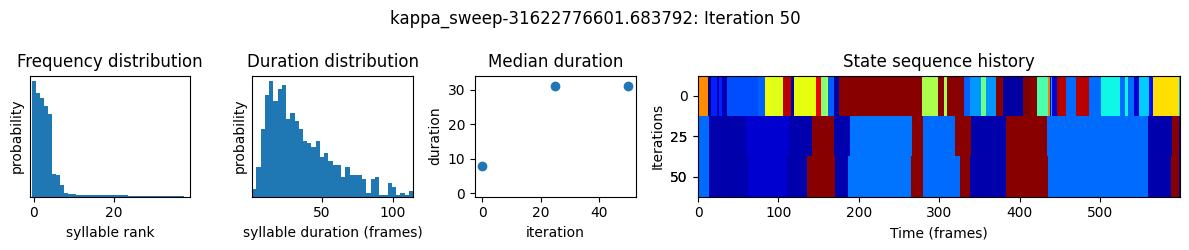

100%|███████████████████████████████████| 51/51 [00:21<00:00,  2.38it/s]


Outputs will be saved to z:\Ben\Projects\StressDASert\Behavior\Scripts
\(2024-09-25_13-43-44)-SleapTrain_Bl6SW_2_test_project\kappa_sweep-316
22776601.683792


 17%|█████▋                            | 25/151 [01:00<05:04,  2.42s/it]

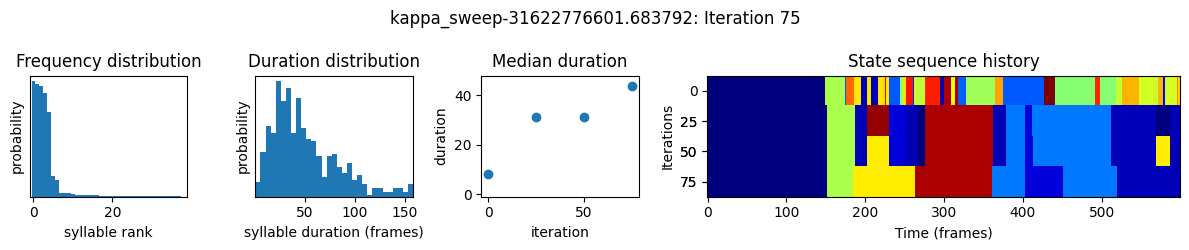

 33%|███████████▎                      | 50/151 [02:00<04:01,  2.39s/it]

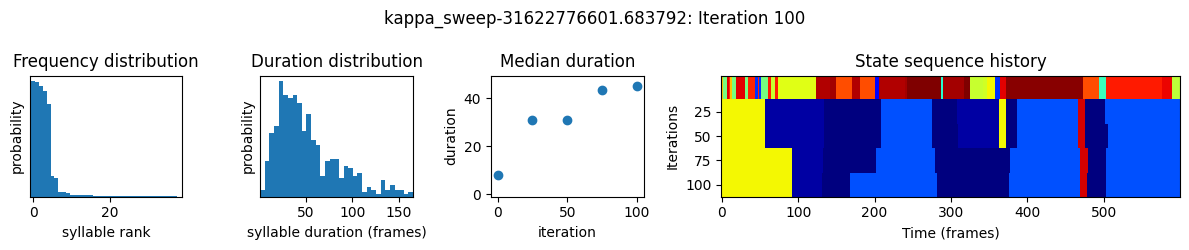

 50%|████████████████▉                 | 75/151 [03:01<03:01,  2.39s/it]

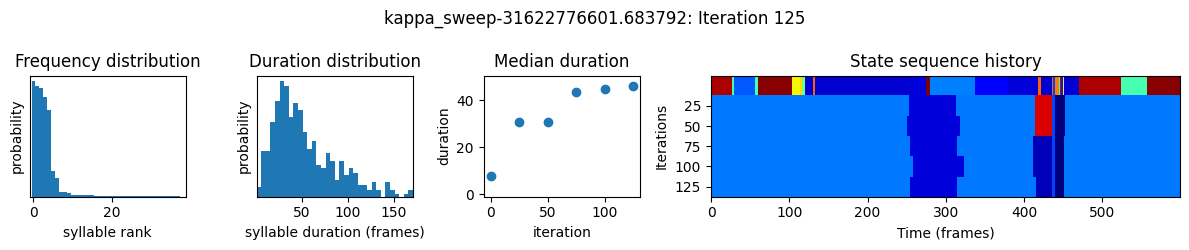

 66%|█████████████████████▊           | 100/151 [04:01<02:00,  2.36s/it]

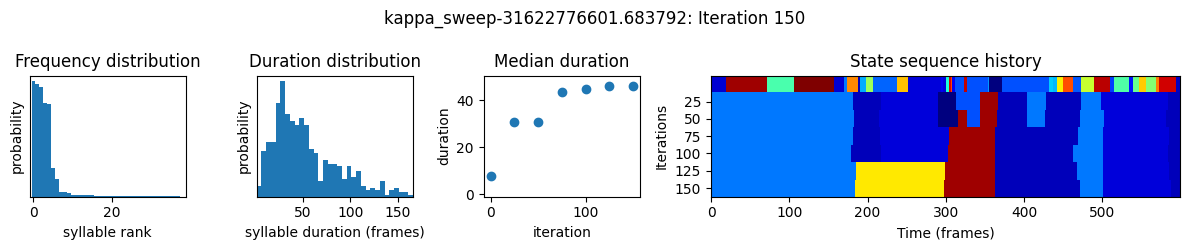

 83%|███████████████████████████▎     | 125/151 [05:19<01:02,  2.42s/it]

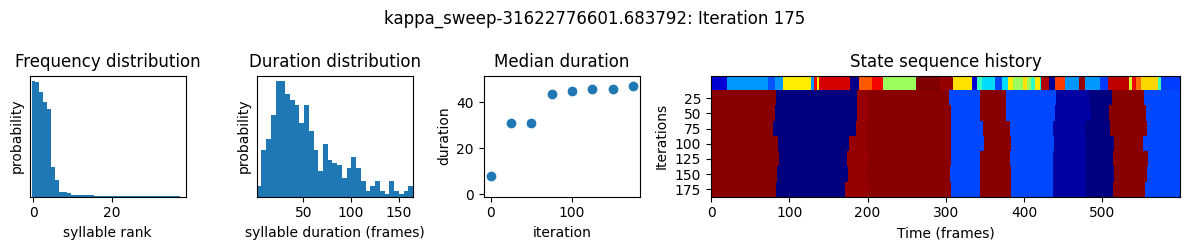

 99%|████████████████████████████████▊| 150/151 [06:47<00:02,  2.40s/it]

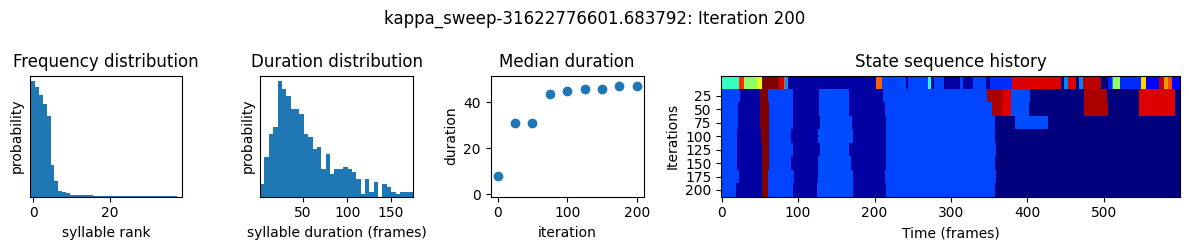

100%|█████████████████████████████████| 151/151 [07:17<00:00,  2.89s/it]


Fitting model with kappa=1000000000000.0
Outputs will be saved to z:\Ben\Projects\StressDASert\Behavior\Scripts
\(2024-09-25_13-43-44)-SleapTrain_Bl6SW_2_test_project\kappa_sweep-100
0000000000.0


 49%|█████████████████▏                 | 25/51 [00:09<00:10,  2.53it/s]

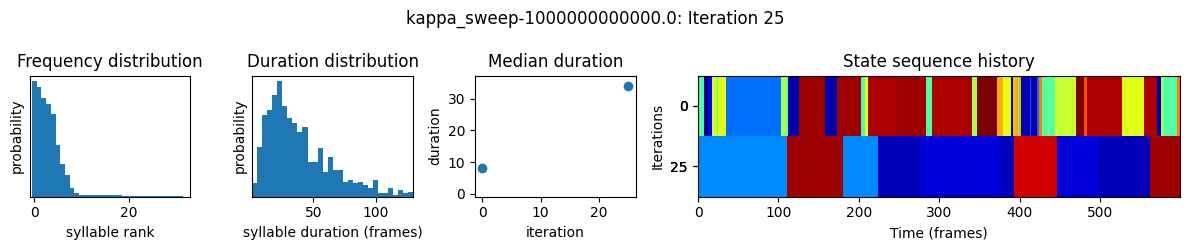

 98%|██████████████████████████████████▎| 50/51 [01:34<00:00,  2.46it/s]

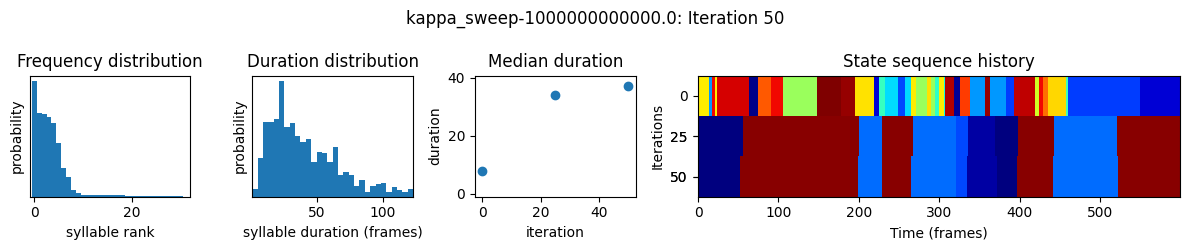

100%|███████████████████████████████████| 51/51 [02:02<00:00,  2.40s/it]


Outputs will be saved to z:\Ben\Projects\StressDASert\Behavior\Scripts
\(2024-09-25_13-43-44)-SleapTrain_Bl6SW_2_test_project\kappa_sweep-100
0000000000.0


 17%|█████▋                            | 25/151 [00:58<04:54,  2.34s/it]

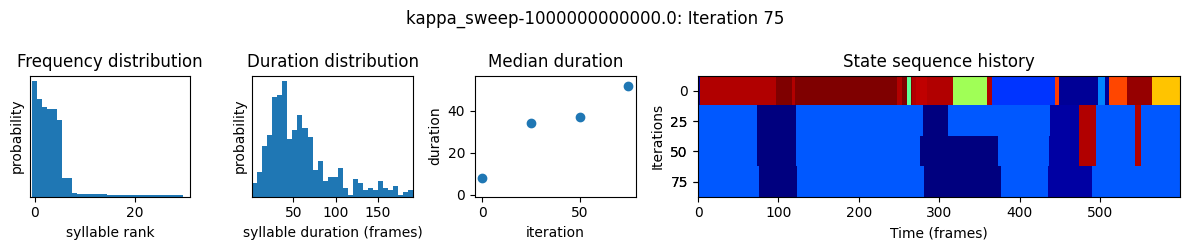

 33%|███████████▎                      | 50/151 [02:56<03:52,  2.31s/it]

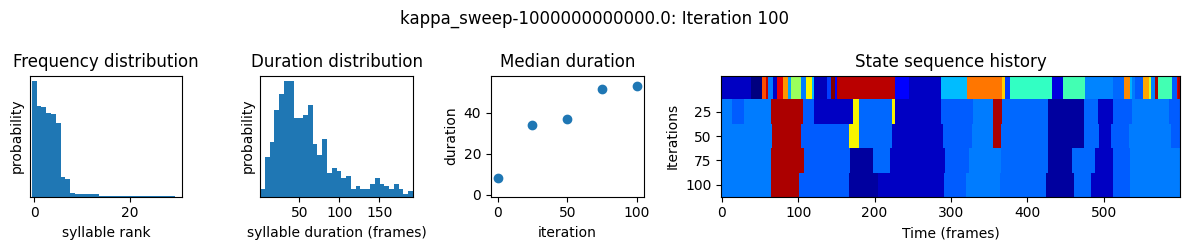

 50%|████████████████▉                 | 75/151 [03:54<02:56,  2.32s/it]

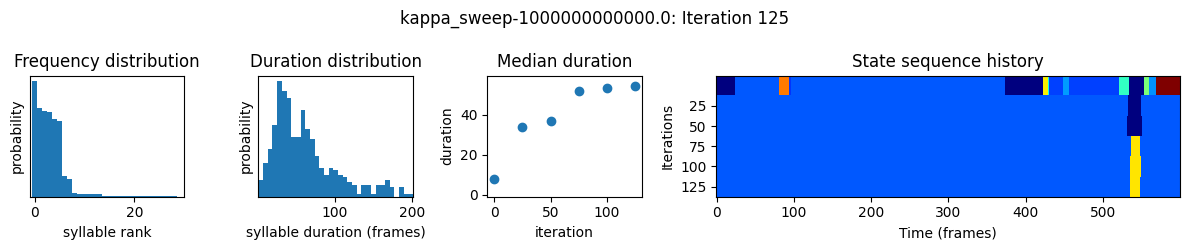

 66%|█████████████████████▊           | 100/151 [05:21<02:03,  2.42s/it]

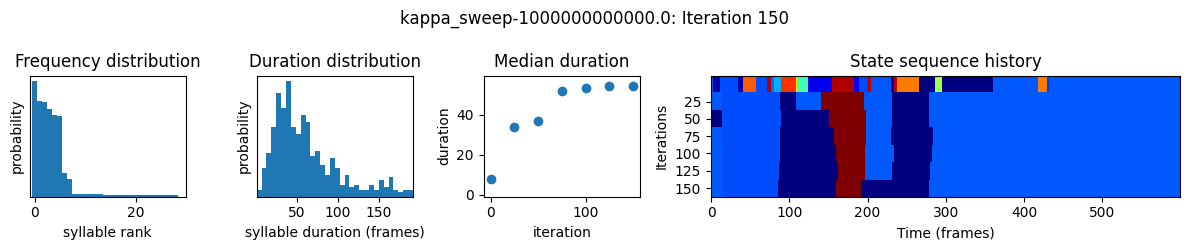

 83%|███████████████████████████▎     | 125/151 [06:52<00:59,  2.28s/it]

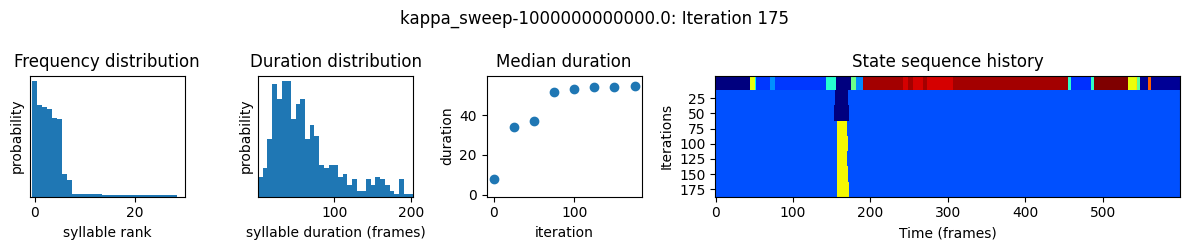

 99%|████████████████████████████████▊| 150/151 [08:37<00:02,  2.26s/it]

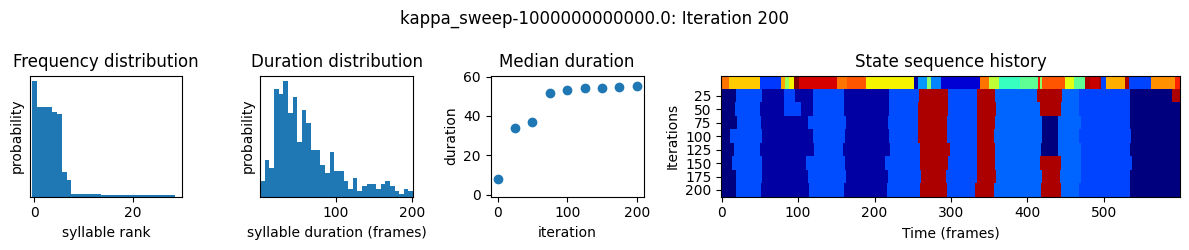

Loading checkpoints: 100%|██████████| 5/5 [03:54<00:00, 46.81s/it]


(<Figure size 800x250 with 2 Axes>, array([20. , 29. , 37.5, 47. , 55. ]))

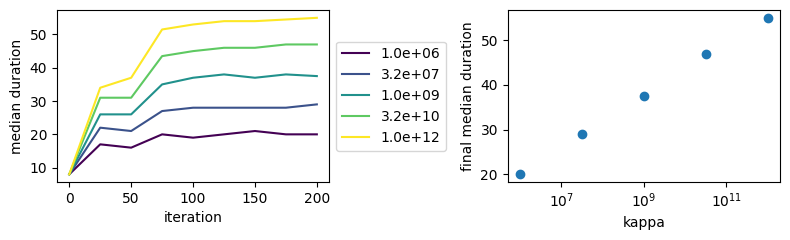

In [9]:
### Sweep a range of kappa values to find one for target motif length.

kappas = np.logspace(6, 12, 5)
decrease_kappa_factor = 10
num_ar_iters = 50
num_full_iters = 200

prefix = "kappa_sweep"

for kappa in kappas:
    print(f"Fitting model with kappa={kappa}")
    model_name = f'{prefix}-{kappa}'
    model = kpms.init_model(data, pca=pca, **config(), location_aware=True)

    # stage 1: fit the model with AR only
    model = kpms.update_hypparams(model, kappa=kappa)
    model = kpms.fit_model(
        model,
        data,
        metadata,
        project_dir,
        model_name,
        ar_only=True,
        num_iters=num_ar_iters,
        save_every_n_iters=25,
        location_aware=True
    )[0];

    # stage 2: fit the full model
    model = kpms.update_hypparams(model, kappa=kappa/decrease_kappa_factor)
    kpms.fit_model(
        model,
        data,
        metadata,
        project_dir,
        model_name,
        ar_only=False,
        start_iter=num_ar_iters,
        num_iters=num_full_iters,
        save_every_n_iters=25,
        location_aware=True
    );

kpms.plot_kappa_scan(kappas, project_dir, prefix)

Kappa = 1e9 targets mean syllable length of ~40 frames or about 1/3 second.

## 4. Model fitting (AR-HMM for initialization)

In [10]:
### Initialize model.

model = kpms.init_model(data, pca=pca, **config(), location_aware=True)
model = kpms.update_hypparams(model, kappa=1e9)

Outputs will be saved to z:\Ben\Projects\StressDASert\Behavior\Scripts
\(2024-09-25_13-43-44)-SleapTrain_Bl6SW_2_test_project\2024_11_07-11_1
6_41


  5%|█▋                                | 25/501 [00:09<02:59,  2.65it/s]

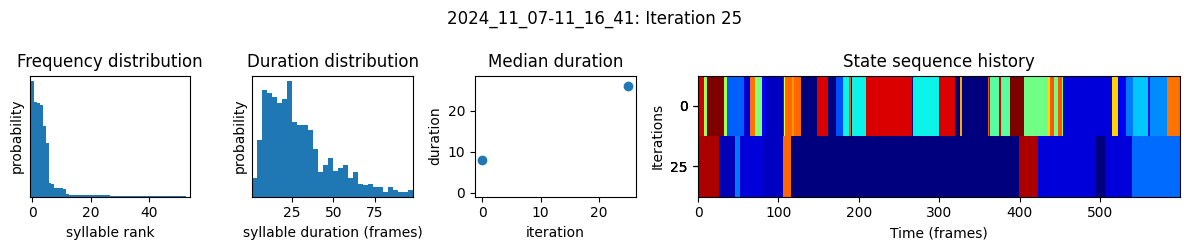

 10%|███▍                              | 50/501 [01:13<02:58,  2.53it/s]

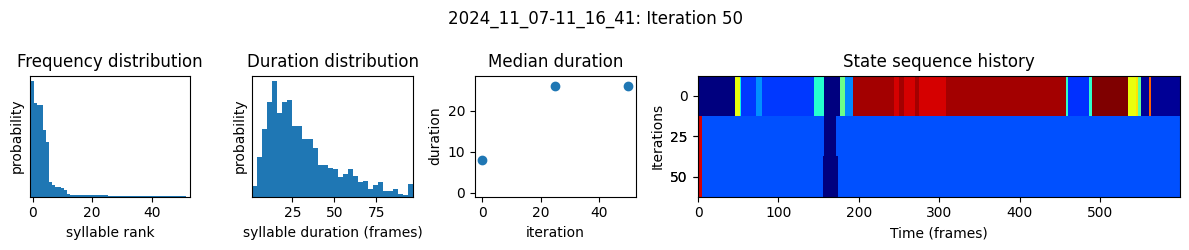

 15%|█████                             | 75/501 [02:20<02:57,  2.40it/s]

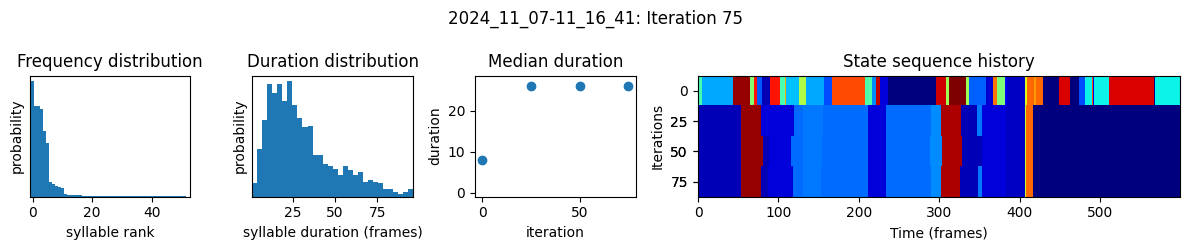

 20%|██████▌                          | 100/501 [03:00<02:39,  2.52it/s]

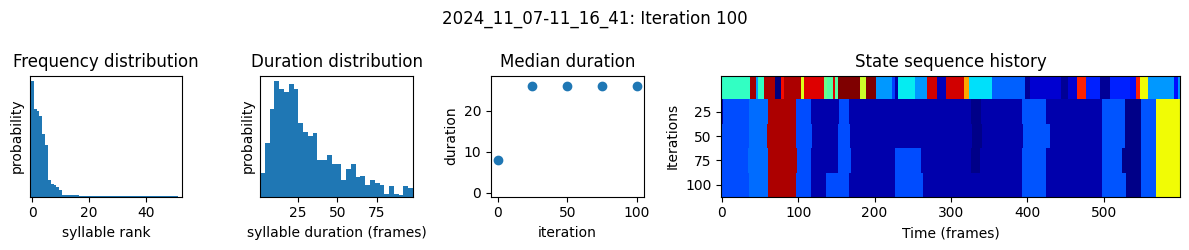

 25%|████████▏                        | 125/501 [03:33<02:26,  2.57it/s]

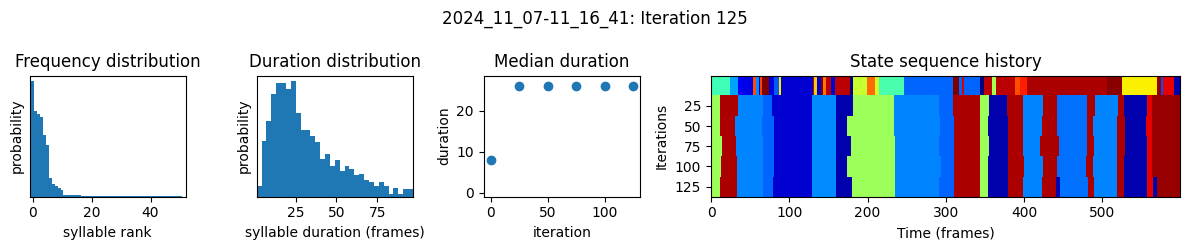

 30%|█████████▉                       | 150/501 [04:48<02:23,  2.45it/s]

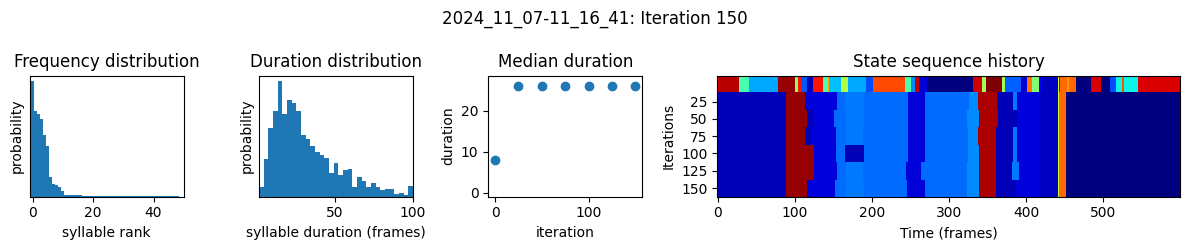

 35%|███████████▌                     | 175/501 [06:00<02:03,  2.63it/s]

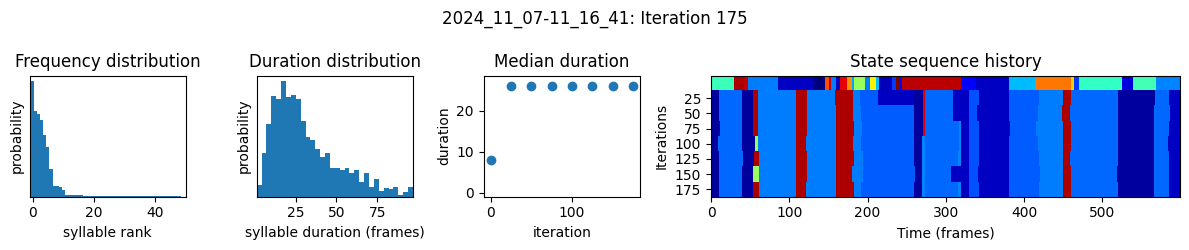

 40%|█████████████▏                   | 200/501 [07:04<02:00,  2.51it/s]

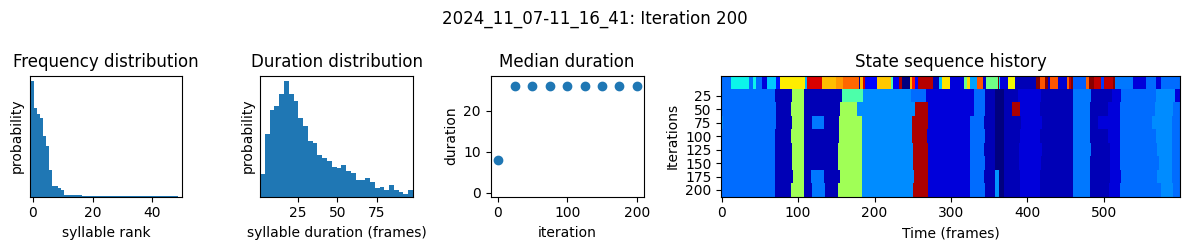

 45%|██████████████▊                  | 225/501 [07:46<01:48,  2.54it/s]

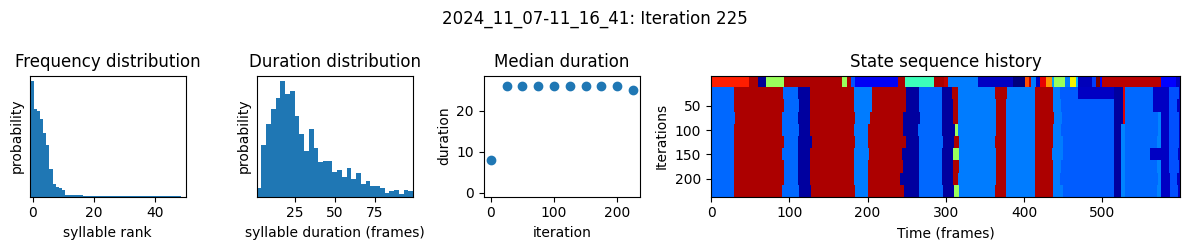

 50%|████████████████▍                | 250/501 [08:27<01:40,  2.50it/s]

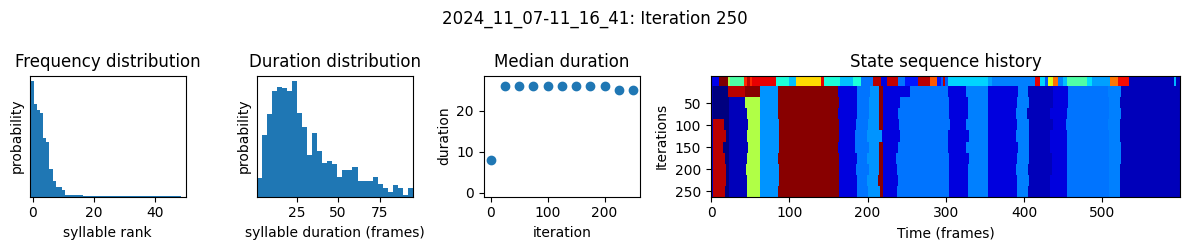

 55%|██████████████████               | 275/501 [09:52<01:35,  2.37it/s]

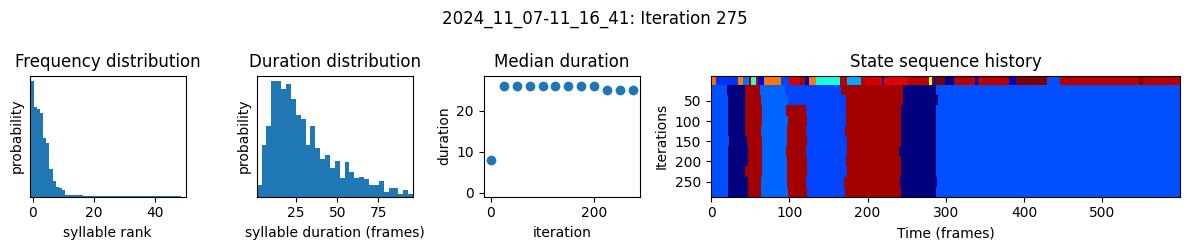

 60%|███████████████████▊             | 300/501 [10:32<01:17,  2.58it/s]

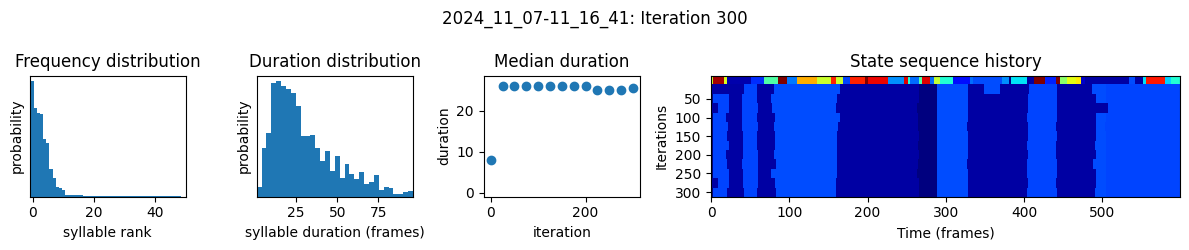

 65%|█████████████████████▍           | 325/501 [11:23<01:14,  2.35it/s]

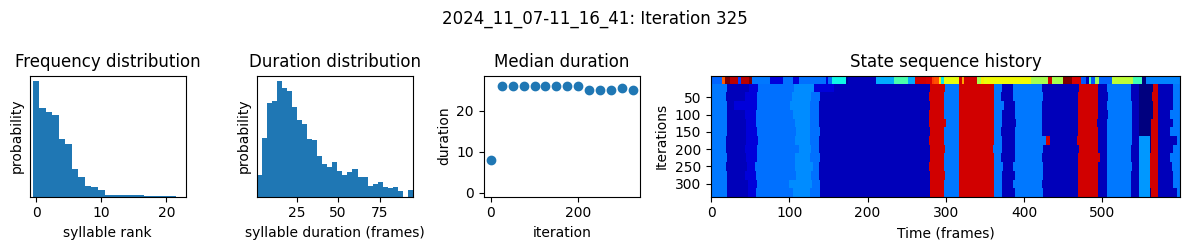

 70%|███████████████████████          | 350/501 [11:57<01:00,  2.48it/s]

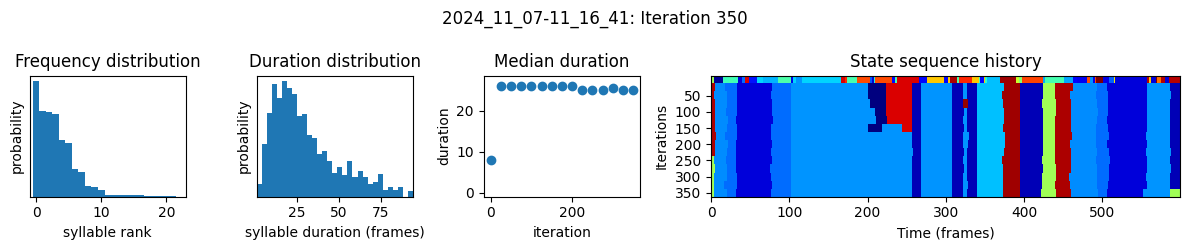

 75%|████████████████████████▋        | 375/501 [12:39<00:49,  2.53it/s]

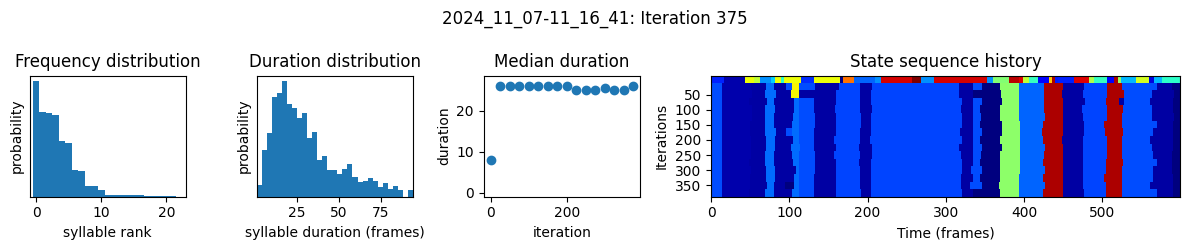

 80%|██████████████████████████▎      | 400/501 [13:19<00:38,  2.63it/s]

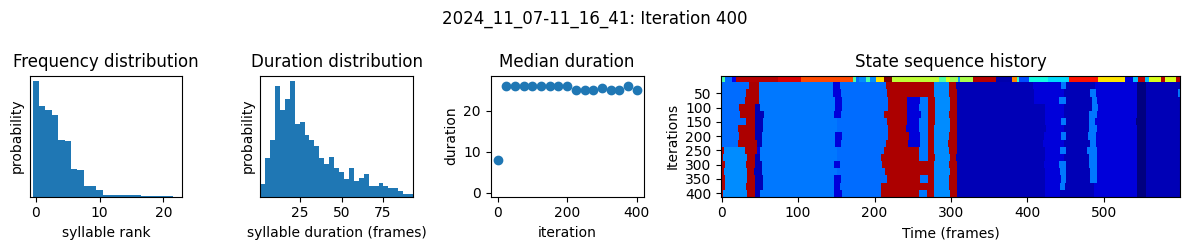

 85%|███████████████████████████▉     | 425/501 [14:13<00:30,  2.52it/s]

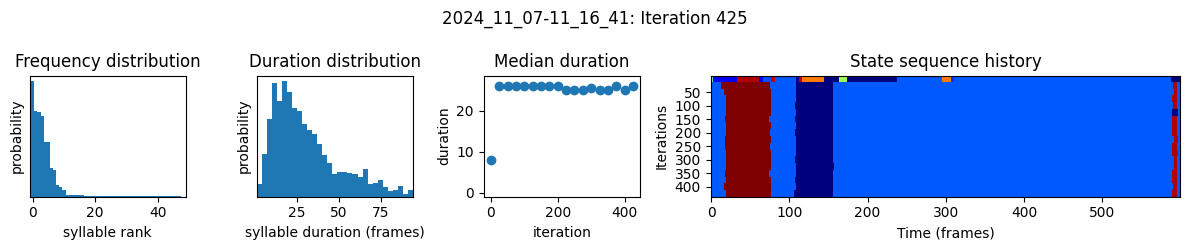

 90%|█████████████████████████████▋   | 450/501 [15:21<00:19,  2.55it/s]

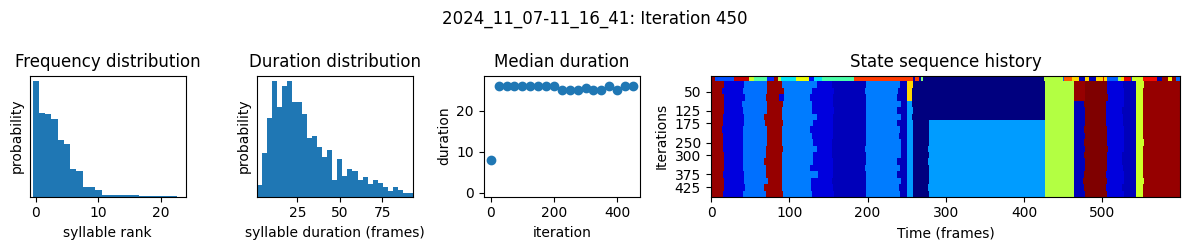

 95%|███████████████████████████████▎ | 475/501 [16:03<00:10,  2.49it/s]

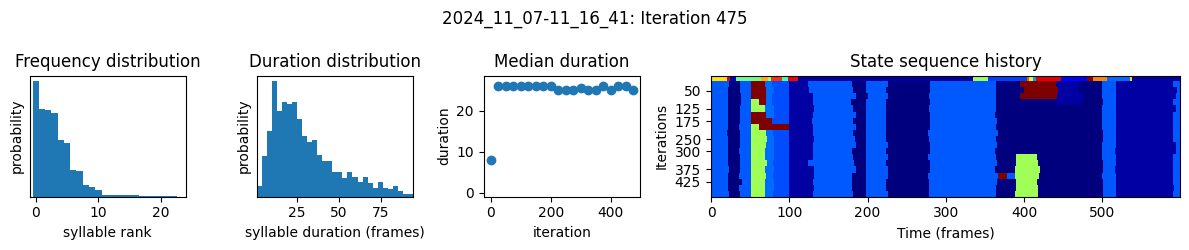

100%|████████████████████████████████▉| 500/501 [16:57<00:00,  2.43it/s]

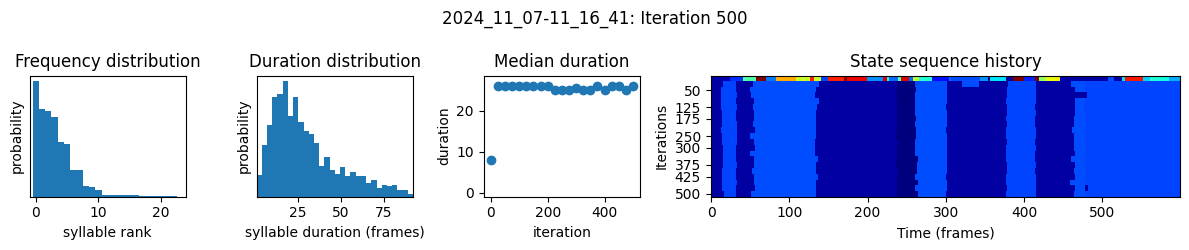

100%|█████████████████████████████████| 501/501 [17:31<00:00,  2.10s/it]


In [11]:
### Fit.

num_ar_iters = 150
model, model_name = kpms.fit_model(model, data, metadata, project_dir, ar_only=True, num_iters=num_ar_iters, location_aware=True)

## 5. Model fitting (SLDS full model)

Outputs will be saved to z:\Ben\Projects\StressDASert\Behavior\Scripts
\(2024-09-25_13-43-44)-SleapTrain_Bl6SW_2_test_project\2024_11_07-11_1
6_41


  5%|█▋                                | 25/501 [00:58<18:22,  2.32s/it]

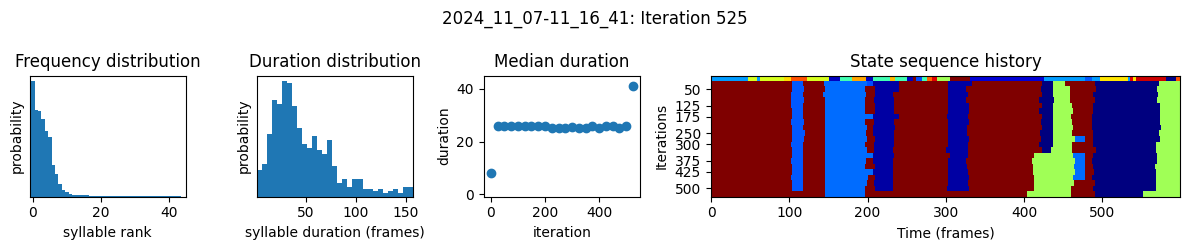

 10%|███▍                              | 50/501 [03:18<18:59,  2.53s/it]

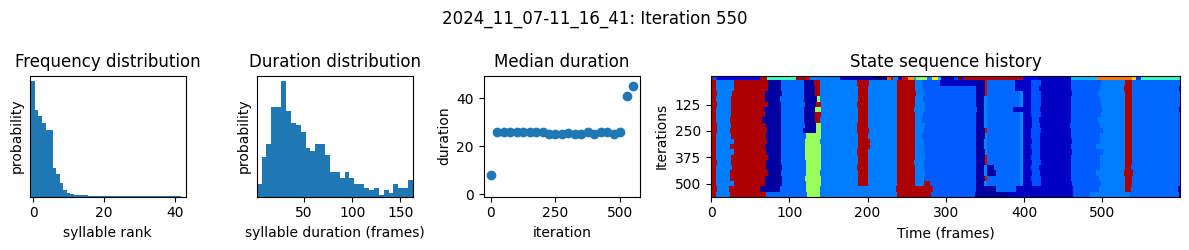

 15%|█████                             | 75/501 [04:29<15:52,  2.24s/it]

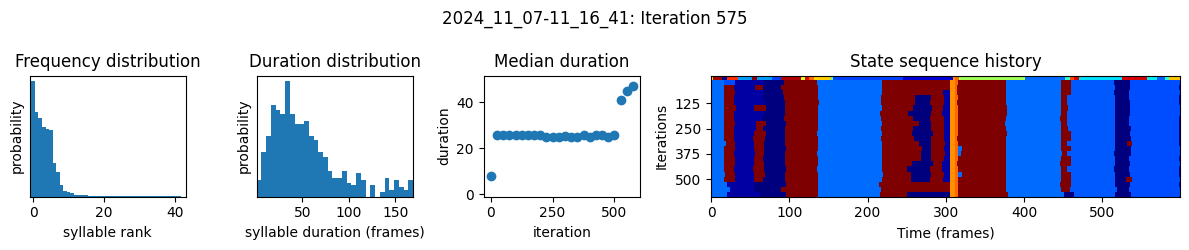

 20%|██████▌                          | 100/501 [05:49<14:52,  2.23s/it]

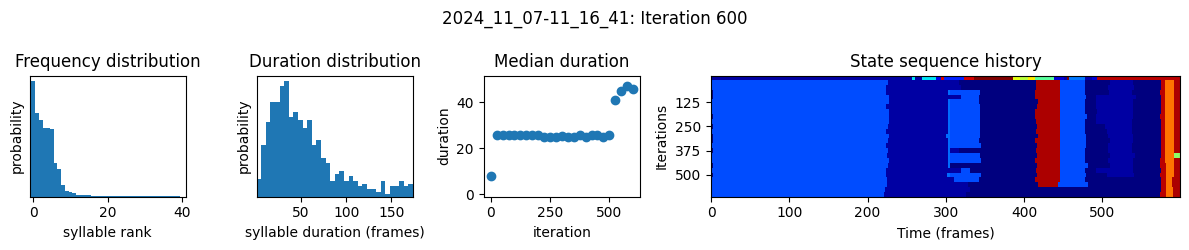

 25%|████████▏                        | 125/501 [07:29<14:20,  2.29s/it]

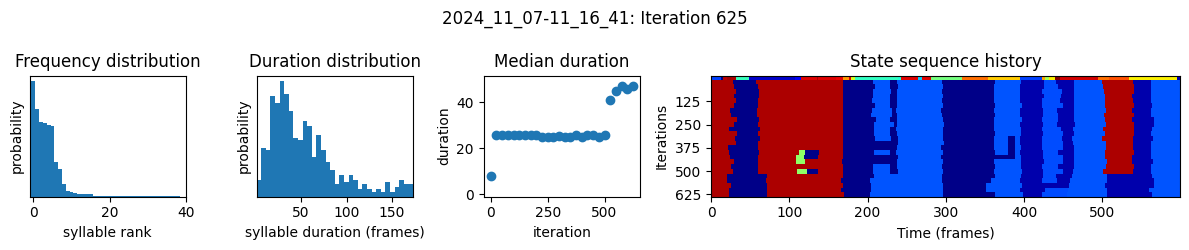

 30%|█████████▉                       | 150/501 [08:28<13:48,  2.36s/it]

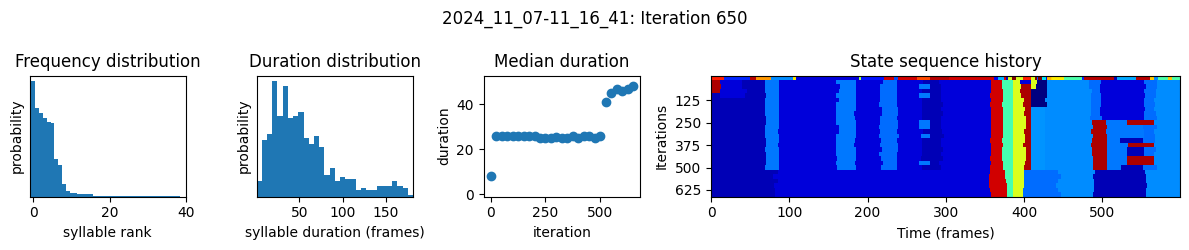

 35%|███████████▌                     | 175/501 [09:27<12:25,  2.29s/it]

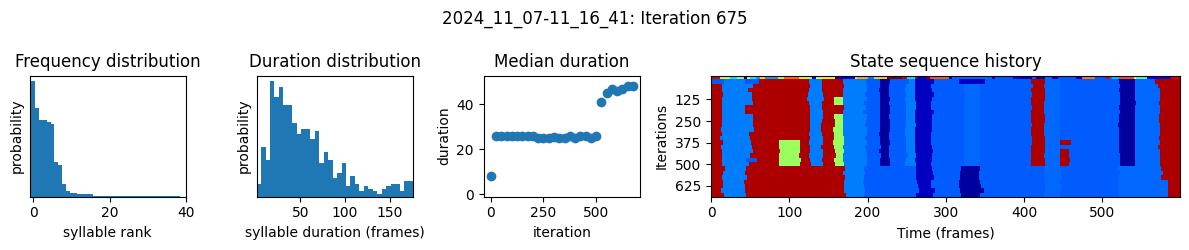

 40%|█████████████▏                   | 200/501 [10:26<11:47,  2.35s/it]

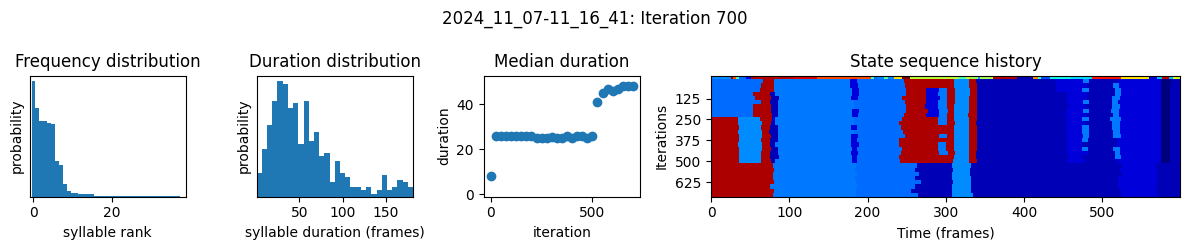

 45%|██████████████▊                  | 225/501 [11:27<10:59,  2.39s/it]

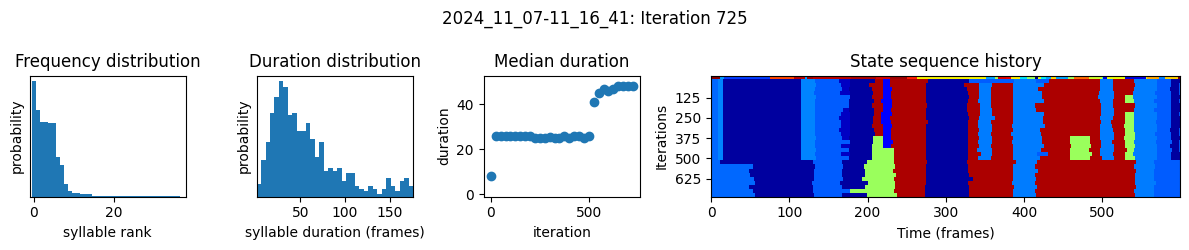

 50%|████████████████▍                | 250/501 [12:27<09:38,  2.30s/it]

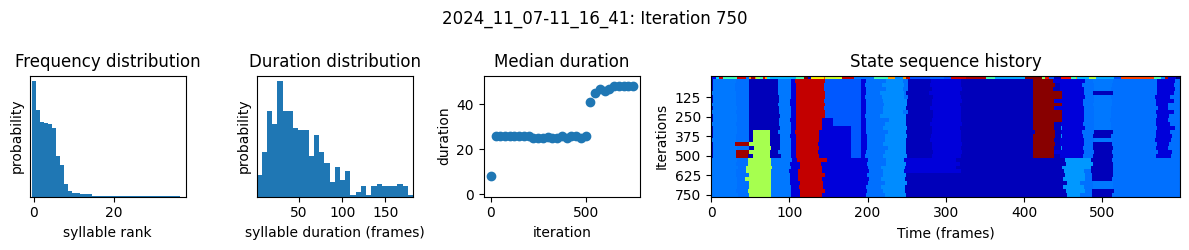

 55%|██████████████████               | 275/501 [13:25<08:37,  2.29s/it]

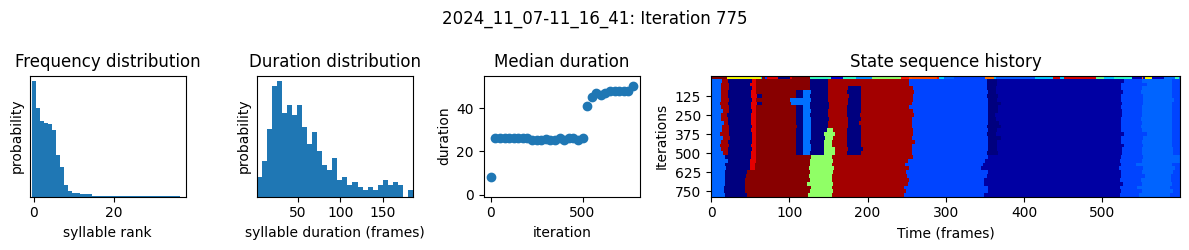

 60%|███████████████████▊             | 300/501 [14:23<07:35,  2.27s/it]

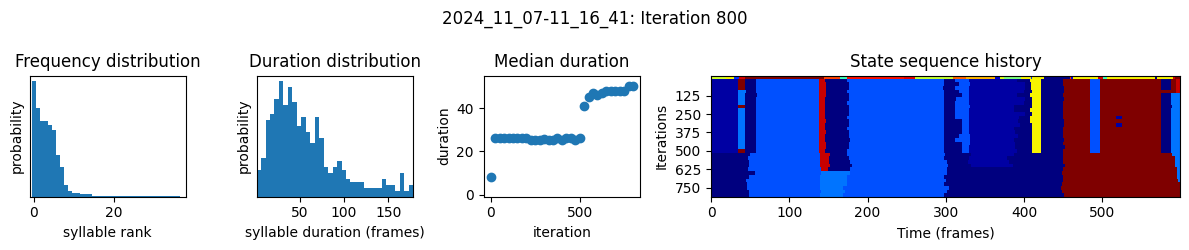

 65%|█████████████████████▍           | 325/501 [15:21<06:44,  2.30s/it]

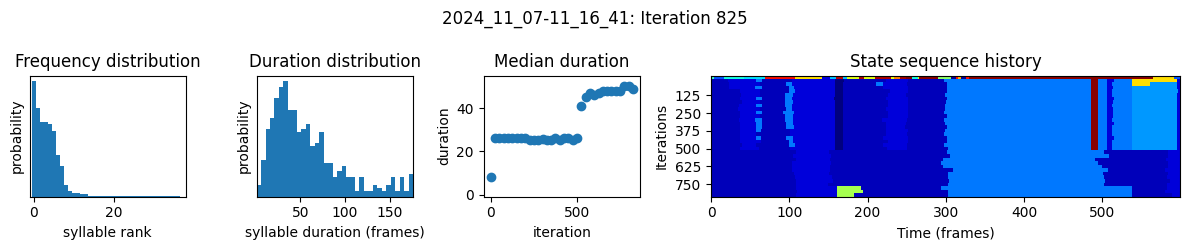

 70%|███████████████████████          | 350/501 [16:20<05:48,  2.31s/it]

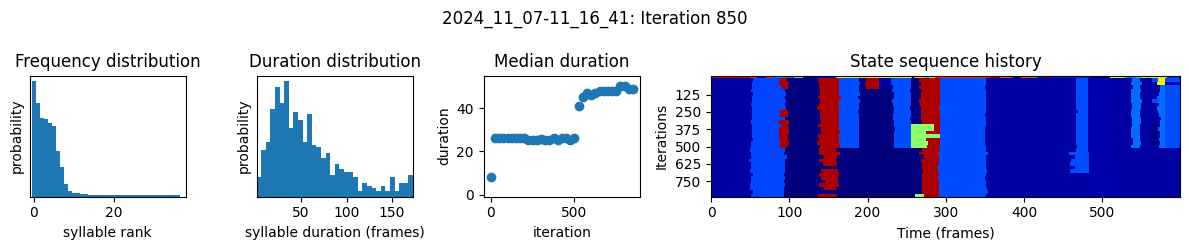

 75%|████████████████████████▋        | 375/501 [17:18<04:47,  2.28s/it]

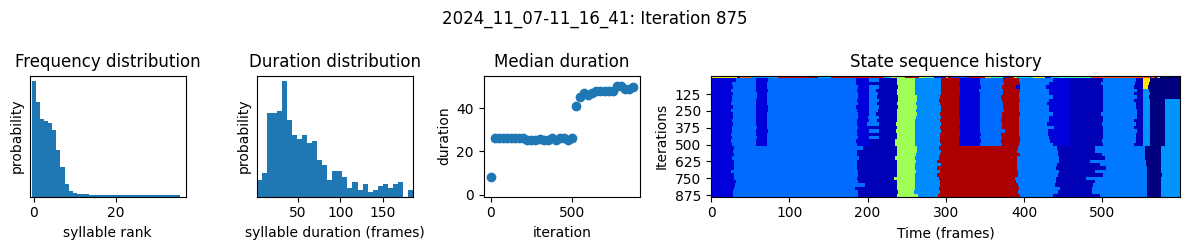

 80%|██████████████████████████▎      | 400/501 [18:16<03:53,  2.31s/it]

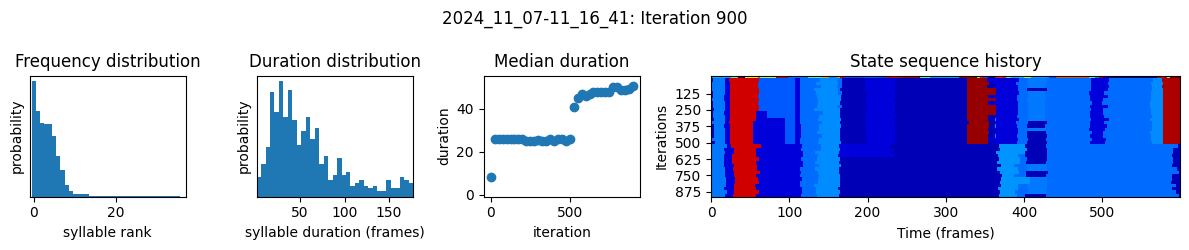

 85%|███████████████████████████▉     | 425/501 [19:15<02:54,  2.29s/it]

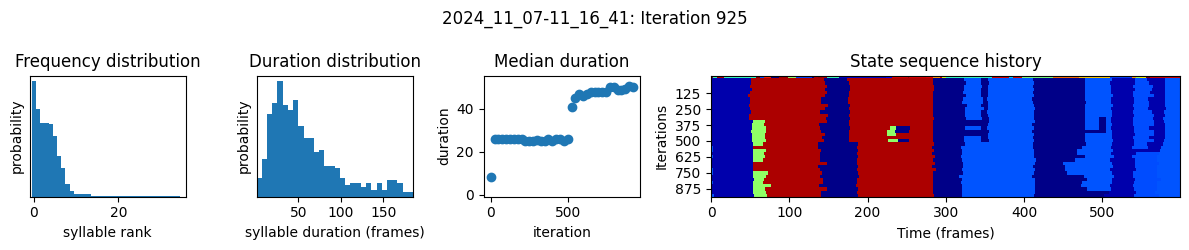

 90%|█████████████████████████████▋   | 450/501 [20:13<01:55,  2.27s/it]

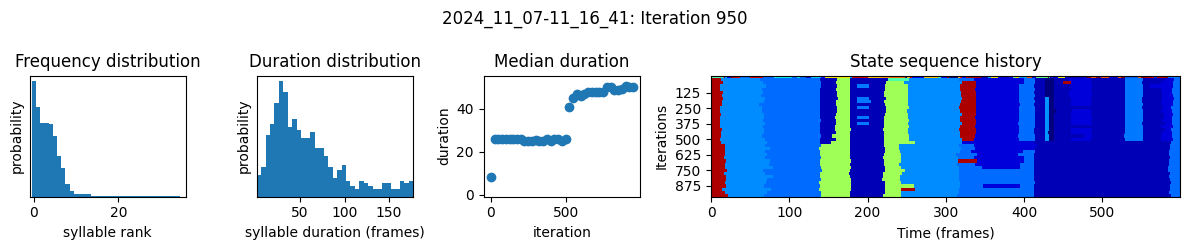

 95%|███████████████████████████████▎ | 475/501 [21:10<00:58,  2.25s/it]

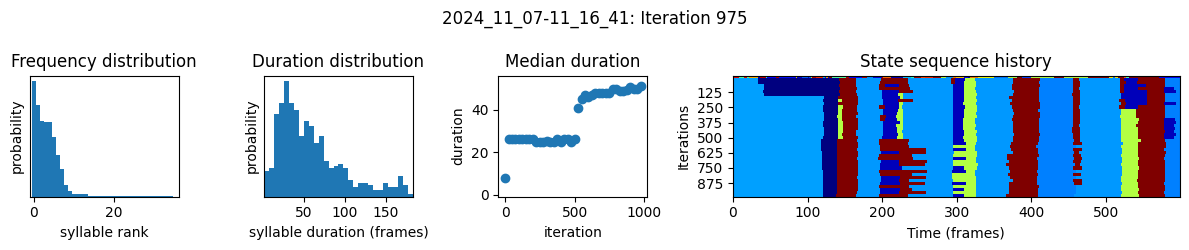

100%|████████████████████████████████▉| 500/501 [22:07<00:02,  2.23s/it]

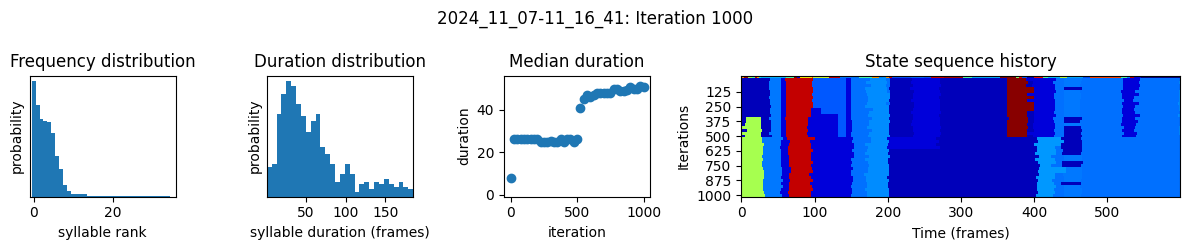

100%|█████████████████████████████████| 501/501 [22:10<00:00,  2.66s/it]


In [12]:
### Load model and checkpoints.

model, data, metadata, current_iter = kpms.load_checkpoint(project_dir, model_name, iteration=num_ar_iters)
model = kpms.update_hypparams(model, kappa=1e10) # NOTE: kappa for the AR-HMM should be larger than for SLDS for syllable length to remain consistent.

### Run SLDS model.

SLDS_iters = 500
model = kpms.fit_model(model, data, metadata, project_dir, model_name, ar_only=False, start_iter=current_iter, num_iters=current_iter + SLDS_iters, location_aware=True)[0]

## 6. Visualizations

In [10]:
### Get model results.

# Load the most recent model checkpoint.
model_name = "2024_11_07-11_16_41" # From the KPMS file.
model, data, metadata, current_iter = kpms.load_checkpoint(project_dir, model_name)

# Extract results.
results = kpms.extract_results(model, metadata, project_dir, model_name)

Saved results to z:\Ben\Projects\StressDASert\Behavior\Scripts\(2024-0
9-25_13-43-44)-SleapTrain_Bl6SW_2_test_project\2024_11_07-11_16_41\res
ults.h5


In [11]:
### Trajectory plot grid (no background video).

results = kpms.load_results(project_dir, model_name)
kpms.generate_grid_movies(
   results,
   project_dir,
   model_name,
   coordinates=coordinates,
   keypoints_only=True,
   keypoints_scale=1,
   use_dims=[0,1], # controls projection plane
   **config());

Writing grid movies to z:\Ben\Projects\StressDASert\Behavior\Scripts\(2024-09-25_13-43-44)-SleapTrain_Bl6SW_2_test_project\2024_11_07-11_16_41\grid_movies
Using window size of 144 pixels


Generating grid movies: 100%|█████████████| 7/7 [00:21<00:00,  3.10s/it]


Saving trajectory plots to z:\Ben\Projects\StressDASert\Behavior\Scripts\(2024-09-25_13-43-44)-SleapTrain_Bl6SW_2_test_project\2024_11_07-11_16_41\trajectory_plots


Generating trajectory plots: 100%|████████| 6/6 [00:01<00:00,  3.38it/s]


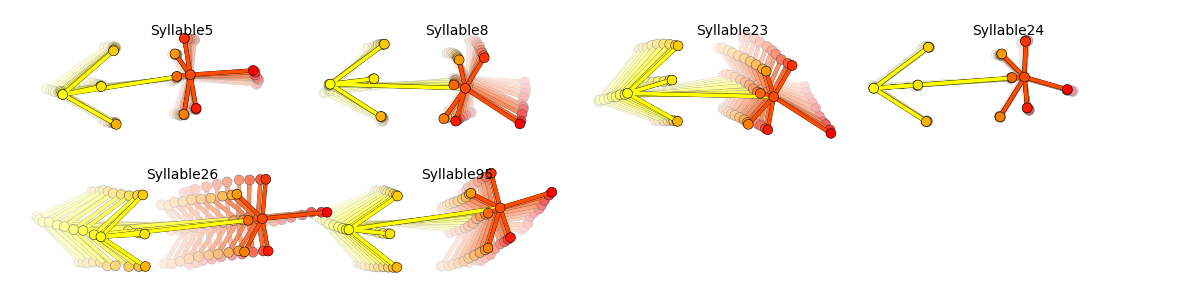

Generating trajectory plots: 100%|████████| 6/6 [00:01<00:00,  3.74it/s]


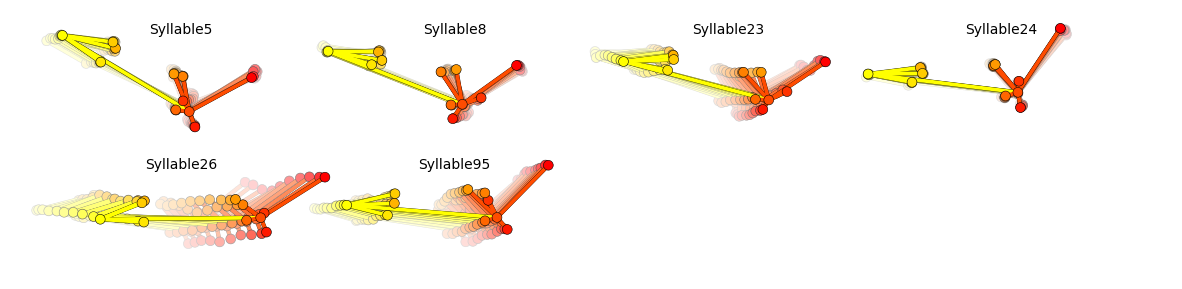

Saved interactive trajectories plot to z:\Ben\Projects\StressDASert\Behavior\Scripts\(2024-09-25_13-43-44)-SleapTrain_Bl6SW_2_test_project\2024_11_07-11_16_41\trajectory_plots\all_trajectories.html


In [18]:
### Trajectory plots.

results = kpms.load_results(project_dir, model_name)
kpms.generate_trajectory_plots(coordinates, results, project_dir, model_name, **config())

Saving dendrogram plot to z:\Ben\Projects\StressDASert\Behavior\Scripts\(2024-09-25_13-43-44)-SleapTrain_Bl6SW_2_test_project\2024_11_07-11_16_41\similarity_dendrogram


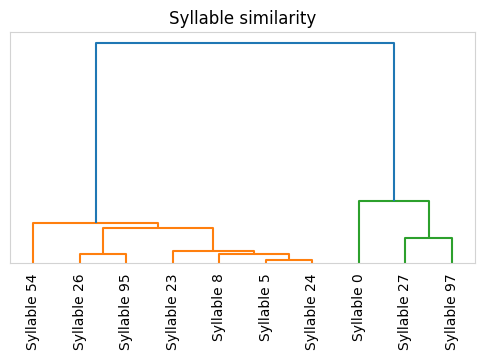

In [29]:
### Syllable similarity dendrogram.

kpms.plot_similarity_dendrogram(coordinates, results, project_dir, model_name, **config())

Group(s): default
Saved figure to z:\Ben\Projects\StressDASert\Behavior\Scripts\(2024-09-25_13-43-44)-SleapTrain_Bl6SW_2_test_project\2024_11_07-11_16_41\figures\transition_matrices.png


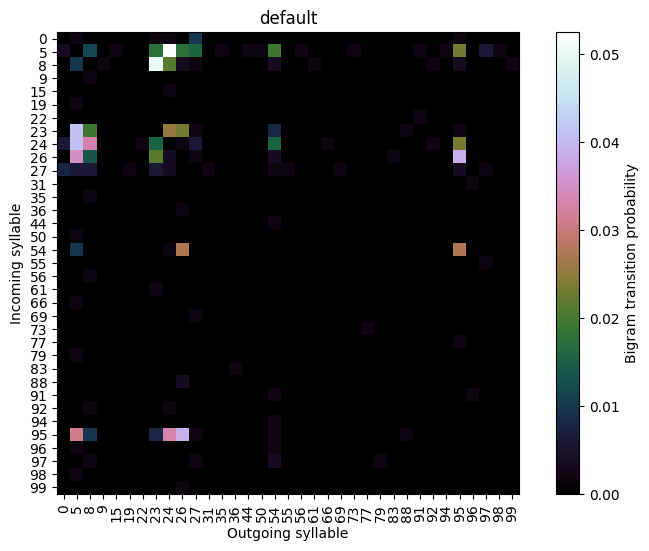

In [71]:
### Transition matrix.

normalize = "bigram" # Normalization method ("bigram", "rows" or "columns").

trans_mats, usages, groups, syll_include=kpms.generate_transition_matrices(
    project_dir, model_name, normalize=normalize,
    min_frequency=0.0 # minimum syllable frequency to include
)    

kpms.visualize_transition_bigram(
    project_dir, model_name, groups, trans_mats, syll_include, normalize=normalize, 
    show_syllable_names=True # label syllables by index (False) or index and name (True)
)

Saved figure to z:\Ben\Projects\StressDASert\Behavior\Scripts\(2024-09-25_13-43-44)-SleapTrain_Bl6SW_2_test_project\2024_11_07-11_16_41\figures\transition_graphs.png


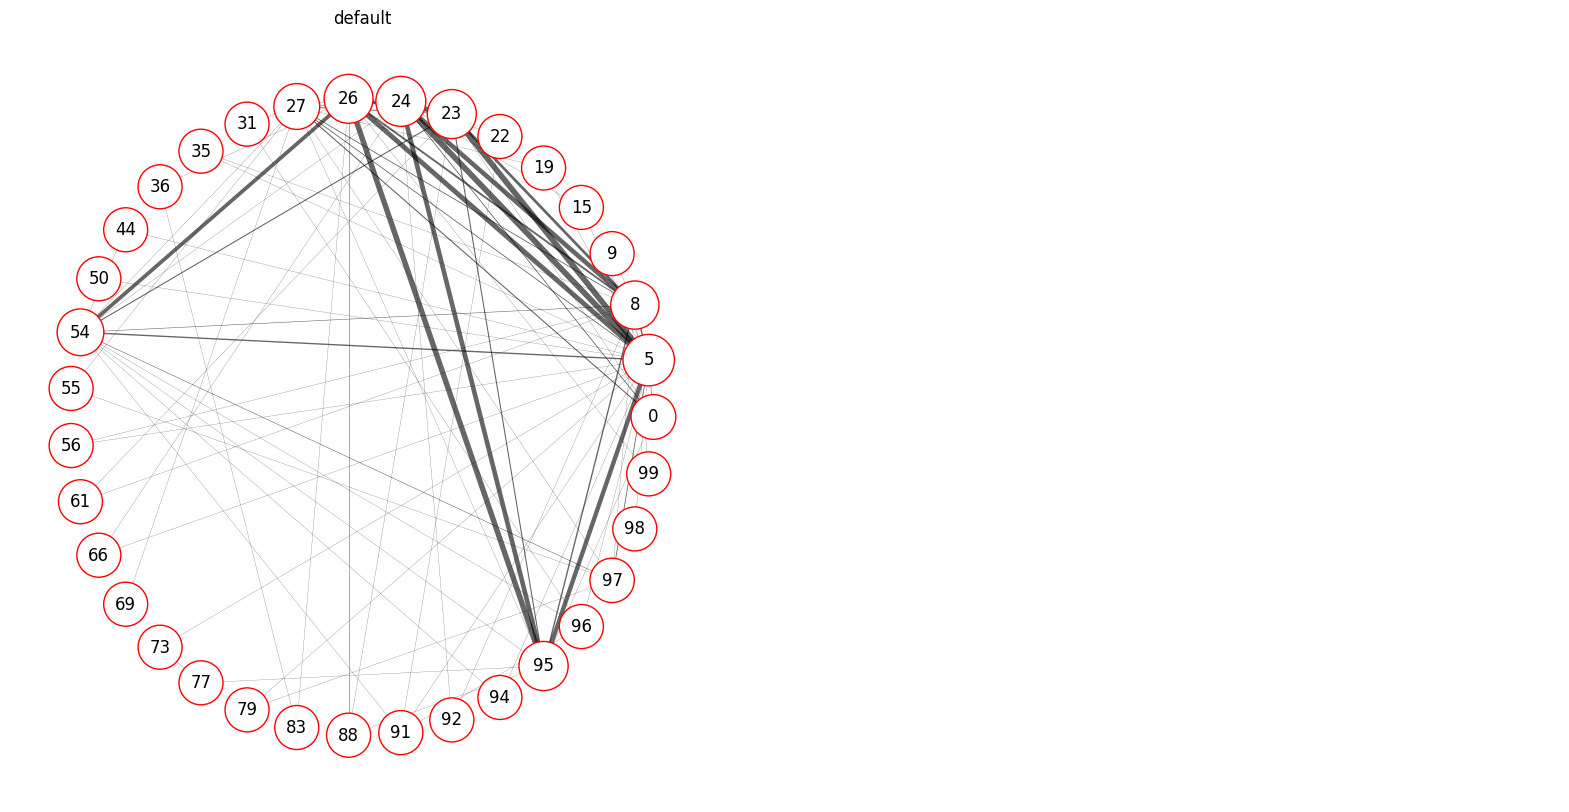

In [54]:
### Transition graph.

kpms.plot_transition_graph_group(
    project_dir, model_name, 
    groups, trans_mats, usages, syll_include, 
    layout="circular",        # transition graph layout ("circular" or "spring")
    show_syllable_names=False # label syllables by index (False) or index and name (True)
)

## 7. Syllable occupancy

Text(0.5, 1.0, 'Syllables')

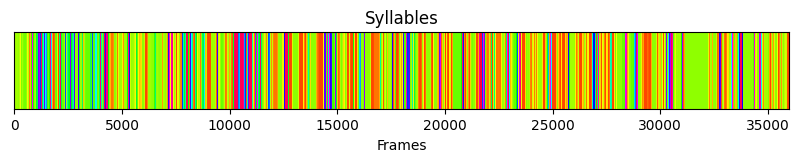

In [60]:
### Plot syllables for the video recording.

# Load results.
results = kpms.load_results(project_dir, model_name)
syllables = results["black_triangulated"]["syllable"]

# Make figure.
np.unique(syllables).shape

fig = plt.figure(figsize=(10, 1))
plt.imshow([syllables], aspect="auto", cmap="hsv")
plt.yticks([])
plt.xlabel("Frames")
plt.title("Syllables")

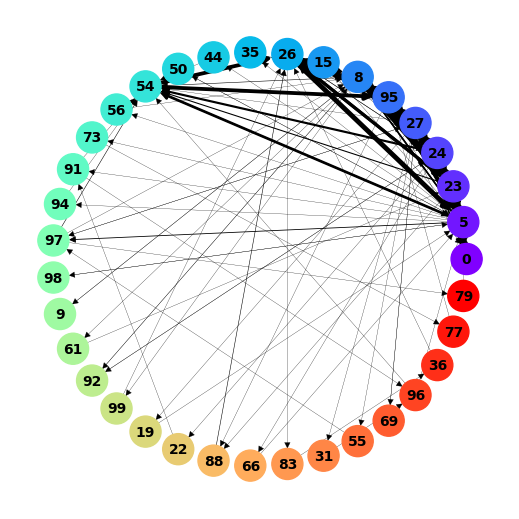

In [93]:
### Make syllables occupancy animation.

# Get transition matrix.
transition_matrix = np.array(trans_mats)[0, ...]
syllable_labels = syll_include

# Make graph figure of the syllables with edge weights as transition probabilities.
G = nx.DiGraph()
for i, row in enumerate(transition_matrix):
    for j, prob in enumerate(row):
        if prob > 0:
            G.add_edge(syllable_labels[i], syllable_labels[j], weight=prob)

# Make figure.
fig = plt.figure(figsize=(5, 5))
pos = nx.circular_layout(G)

# Generate a color map for the nodes
colors = plt.cm.rainbow(np.linspace(0, 1, len(G.nodes())))

# Get edge weights for thickness
edges = G.edges(data=True)
weights = [edge[2]["weight"] * 100 for edge in edges]  # Multiply by a factor to make the differences more visible

# Draw the graph
nx.draw(G, pos, with_labels=True, node_size=500, node_color=colors, font_size=10, font_weight="bold", edge_color="black", width=weights)


In [ ]:
### Make syllable occupancy animation.

# Create the directed graph with edge weights as transition probabilities.
G = nx.DiGraph()
for i, row in enumerate(transition_matrix):
    for j, prob in enumerate(row):
        if prob > 0:
            G.add_edge(syllable_labels[i], syllable_labels[j], weight=prob)

# Position the nodes in a circular layout.
pos = nx.circular_layout(G)

# Get edge weights for line thickness.
edge_thickness_scalar = 100
edges = G.edges(data=True)
weights = [edge[2]["weight"] * edge_thickness_scalar for edge in edges]

# Prepare the figure.
fig, ax = plt.subplots(figsize=(5, 5), dpi=300)
ax.axis("off")

# Get the size of the figure in pixels.
fig.canvas.draw()
width, height = fig.canvas.get_width_height()
width = int(width)
height = int(height)

# Set up the OpenCV VideoWriter.
fps = 120.0
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
video = cv2.VideoWriter("../Figures/syllable_occupancy.mp4", fourcc, fps, (width, height))

# Make a color vector: one color for each syllable.
colors = plt.cm.rainbow(np.linspace(0, 1, len(G.nodes())))

# List of nodes.
node_list = list(G.nodes())

# Draw edges and labels once (they don't change).
nx.draw_networkx_edges(G, pos, ax=ax, edge_color="black", width=weights)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=10, font_weight="bold")

# Initialize node colors (all grey).
node_colors = ["grey"] * len(node_list)

# Draw nodes once and get the node collection.
node_collection = nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=300)

# Generate frames and write to the video.
for frame in trange(len(syllables), desc="Making syllable occupancy video"):
    # Update node colors.
    node_colors = ["grey"] * len(node_list)
    current_syllable = syllables[frame]
    if current_syllable in node_list:
        idx = node_list.index(current_syllable)
        node_colors[idx] = colors[idx]

    # Update the colors of the nodes in the collection.
    node_collection.set_color(node_colors)

    # Render the plot to a numpy array.
    fig.canvas.draw()
    img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
    img = img.reshape((height, width, 3))

    # Convert RGB to BGR for OpenCV.
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    # Write the frame to the video.
    video.write(img)

# Release the VideoWriter and close the figure.
video.release()
plt.close(fig)

Making syllable occupancy video:   0%|          | 0/36001 [00:00<?, ?it/s]C:\Users\bm9751\AppData\Local\Temp\ipykernel_49584\1307831589.py:63: MatplotlibDeprecationWarning:

The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed two minor releases later. Use buffer_rgba instead.

Making syllable occupancy video:   1%|▏         | 518/36001 [00:37<42:55, 13.78it/s]